In [1]:
import sys
import os

sys.path.append(r"C:\Users\Msfin\cloned_repositories\CA1-interneuron-GLM")
from GLM_regression import *
from functions_plotting_reconstruction_MSE import *
import pickle
import os
import numpy as np
import matplotlib.pyplot as plt
import os
import torch
import slicetca
import h5py
import utils as ut
import plot as pt
import warnings
plt.rcParams.update({'font.size': 12,
                     'axes.spines.right': False,
                     'axes.spines.top':   False,
                     'legend.frameon':    False,})

%load_ext autoreload
%autoreload 

C:\Users\Msfin\cloned_repositories\CA1-interneuron-GLM\utils.py:7: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
import sys
from scipy.stats import sem
sys.path.append(r'C:\Users\Msfin\cloned_repositories\CA1-interneuron-GLM')

from utils_TCA_clustering_scratchpad import *
from GLM_regression_plotting import *

In [5]:
activity_dict, double_predicted_activity_dict_NDNF_new, filtered_factors_dict, double_new_NDNF_activity_dict, double_new_NDNF_velocity_dict, double_residual_activity_dict_NDNF_new = load_data_double(name="NDNFanalC", double_track=False)
# activity_dict, filtered_factors_dict, double_new_NDNF_activity_dict_100, double_new_NDNF_velocity_dict_100, double_residual_activity_dict_NDNF_new_100 = load_data_double(name="NDNFanalC", double_track=True)

GLM_params, activity_dict, double_predicted_activity_dict_NDNF_new, factors_dict, filtered_factors_dict, residual_activity_dict_NDNF_new = load_data_regular(name="NDNFanalC", new_NDNF=True)
GLM_params_old_NDNF, activity_dict_old_NDNF, double_predicted_activity_dict_NDNF_old, factors_dict_old_NDNF, filtered_factors_dict_old_NDNF, residual_activity_dict_NDNF_old = load_data_regular(name="NDNFindivsomata_GLM", new_NDNF=False)
GLM_params_SST, activity_dict_SST, double_predicted_activity_dict_SST, factors_dict_SST, filtered_factors_dict_SST, residual_activity_dict_SST = load_data_regular(name="SSTindivsomata_GLM", new_NDNF=False)
GLM_params_EC, activity_dict_EC, double_predicted_activity_dict_EC, factors_dict_EC, filtered_factors_dict_EC, residual_activity_dict_EC = load_data_regular(name="EC_GLM", new_NDNF=False)


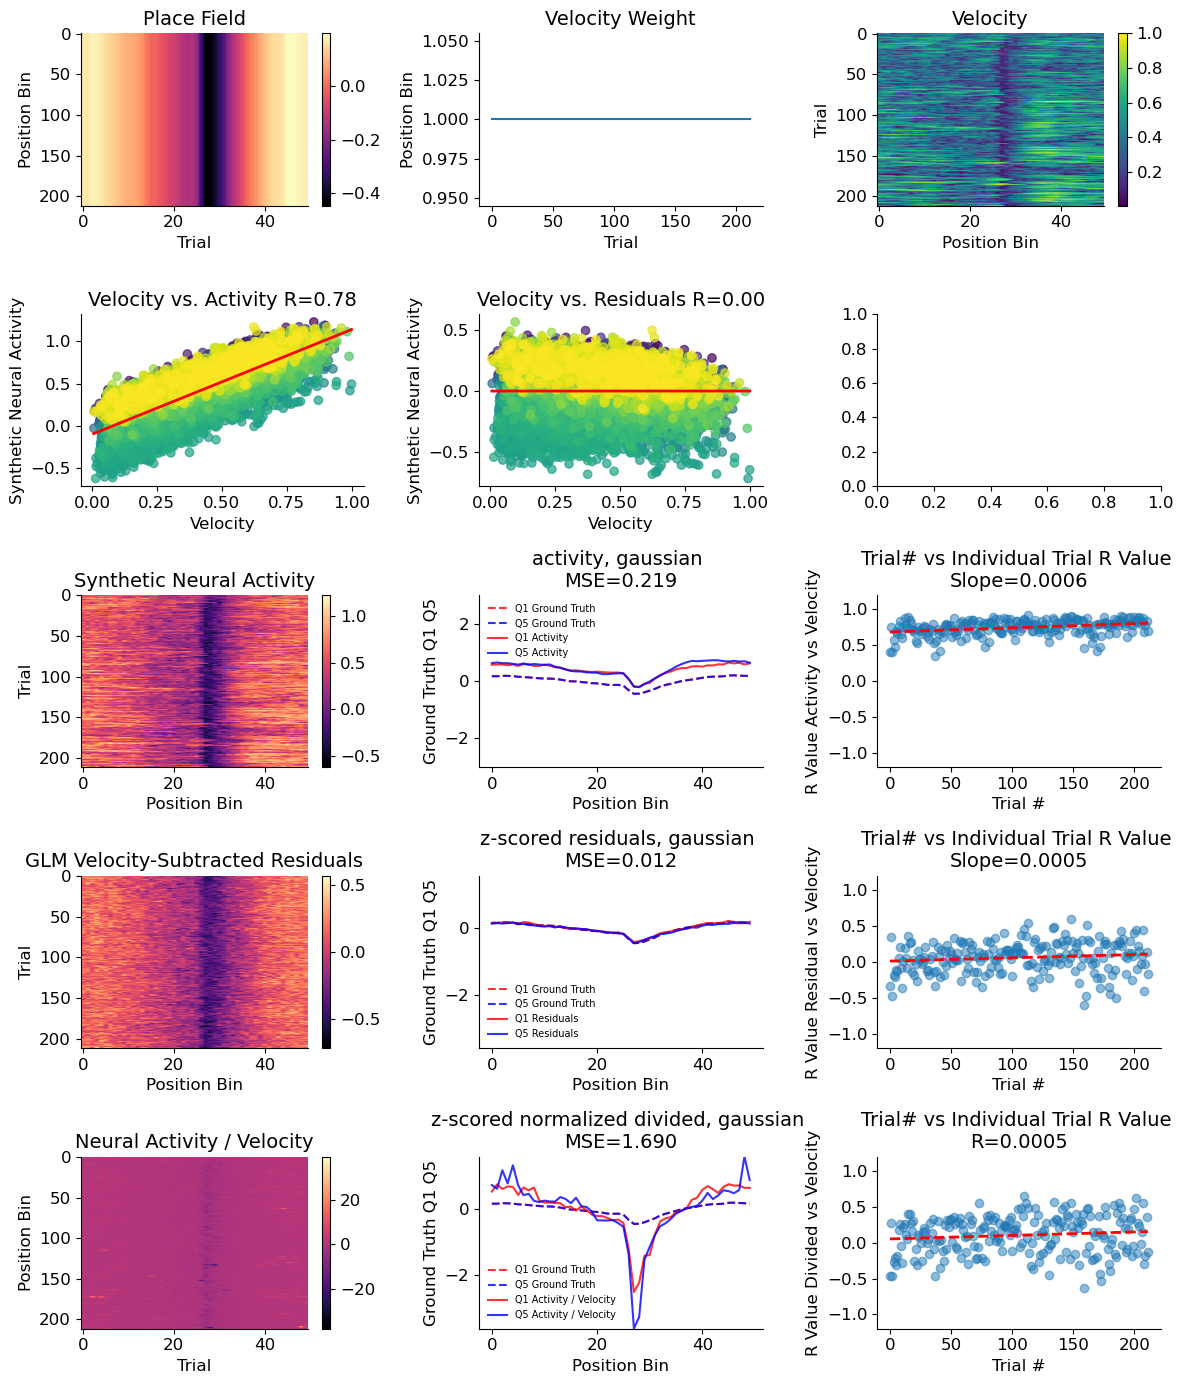

In [4]:
########## plotting synthetic model to show GLM efficacy 

# options for velocity_weight_type = ramping_weight or flat_weight

# options for place field type = "flat", "positive_ramp", "negative_ramp", "step", "BTSP", "EC"
    
MSE_activity, MSE_residual, MSE_divided, velocity_weight, place_field, velocity, residual, combined_activity, divided_array, predicted_array, place_field_type, z_score = get_synthetic_data(activity_dict_SST, factors_dict_SST, velocity_weight_type="ramping_weight", noise_scale=0.1, place_field_type="flat", use_GAM=False, velocity_power=1, velocity_weight=1, place_field_shift=0, place_field_scale=0, z_score=False)

plot_synthetic_data_seperate_quintiles(MSE_activity, MSE_residual, MSE_divided, place_field, velocity, residual, combined_activity, divided_array, predicted_array, velocity_weight, place_field_type=place_field_type, z_score=z_score)
        

which_MSE=residual


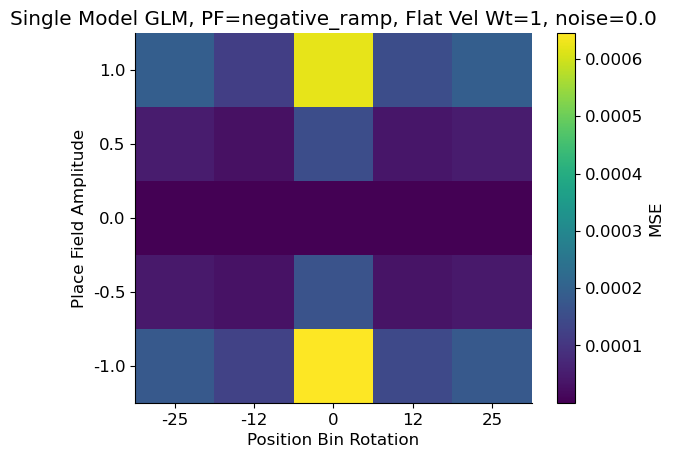

In [5]:
######## plotting MSE scores to show that GLM does well in different place field amplitudes and locations 

get_MSE_array_and_plot(activity_dict_SST, factors_dict_SST, velocity_weight_type="flat", noise_scale=0., place_field_type="negative_ramp", use_GAM=False, velocity_power=1, velocity_weight=1, multimodel=False, z_score=False, which_MSE="residual")


Loaded: timebins_loss_dict_EC_latent_2_2_animal0.pkl
Loaded: timebins_loss_dict_EC_latent_2_2_animal1.pkl
Loaded: timebins_loss_dict_EC_latent_2_2_animal2.pkl
Loaded: timebins_loss_dict_EC_latent_2_2_animal3.pkl
Loaded: timebins_loss_dict_EC_latent_2_2_animal4.pkl
Loaded: timebins_loss_dict_EC_latent_2_2_animal5.pkl
Loaded: timebins_loss_dict_EC_latent_2_2_animal6.pkl
Total floats for latent 2: 7

Loaded: timebins_loss_dict_EC_latent_3_3_animal0.pkl
Loaded: timebins_loss_dict_EC_latent_3_3_animal1.pkl
Loaded: timebins_loss_dict_EC_latent_3_3_animal2.pkl
Loaded: timebins_loss_dict_EC_latent_3_3_animal3.pkl
Loaded: timebins_loss_dict_EC_latent_3_3_animal4.pkl
Loaded: timebins_loss_dict_EC_latent_3_3_animal5.pkl
Loaded: timebins_loss_dict_EC_latent_3_3_animal6.pkl
Total floats for latent 3: 7

Loaded: timebins_loss_dict_EC_latent_4_4_animal0.pkl
Loaded: timebins_loss_dict_EC_latent_4_4_animal1.pkl
Loaded: timebins_loss_dict_EC_latent_4_4_animal2.pkl
Loaded: timebins_loss_dict_EC_latent_4_

Loaded: timebins_loss_dict_EC_latent_53_53_animal0.pkl
Loaded: timebins_loss_dict_EC_latent_53_53_animal1.pkl
Loaded: timebins_loss_dict_EC_latent_53_53_animal2.pkl
Loaded: timebins_loss_dict_EC_latent_53_53_animal3.pkl
Loaded: timebins_loss_dict_EC_latent_53_53_animal4.pkl
Loaded: timebins_loss_dict_EC_latent_53_53_animal5.pkl
Loaded: timebins_loss_dict_EC_latent_53_53_animal6.pkl
Total floats for latent 53: 7

Loaded: timebins_loss_dict_EC_latent_54_54_animal0.pkl
Loaded: timebins_loss_dict_EC_latent_54_54_animal1.pkl
Loaded: timebins_loss_dict_EC_latent_54_54_animal2.pkl
Loaded: timebins_loss_dict_EC_latent_54_54_animal3.pkl
Loaded: timebins_loss_dict_EC_latent_54_54_animal4.pkl
Loaded: timebins_loss_dict_EC_latent_54_54_animal5.pkl
Loaded: timebins_loss_dict_EC_latent_54_54_animal6.pkl
Total floats for latent 54: 7

Loaded: timebins_loss_dict_EC_latent_55_55_animal0.pkl
Loaded: timebins_loss_dict_EC_latent_55_55_animal1.pkl
Loaded: timebins_loss_dict_EC_latent_55_55_animal2.pkl
Loa

Loaded: timebins_loss_dict_NDNF_latent_45_45_animal0.pkl
Loaded: timebins_loss_dict_NDNF_latent_45_45_animal1.pkl
Loaded: timebins_loss_dict_NDNF_latent_45_45_animal2.pkl
Loaded: timebins_loss_dict_NDNF_latent_45_45_animal3.pkl
Total floats for latent 45: 4

Loaded: timebins_loss_dict_NDNF_latent_46_46_animal0.pkl
Loaded: timebins_loss_dict_NDNF_latent_46_46_animal1.pkl
Loaded: timebins_loss_dict_NDNF_latent_46_46_animal2.pkl
Loaded: timebins_loss_dict_NDNF_latent_46_46_animal3.pkl
Total floats for latent 46: 4

Loaded: timebins_loss_dict_NDNF_latent_47_47_animal0.pkl
Loaded: timebins_loss_dict_NDNF_latent_47_47_animal1.pkl
Loaded: timebins_loss_dict_NDNF_latent_47_47_animal2.pkl
Loaded: timebins_loss_dict_NDNF_latent_47_47_animal3.pkl
Total floats for latent 47: 4

Loaded: timebins_loss_dict_NDNF_latent_48_48_animal0.pkl
Loaded: timebins_loss_dict_NDNF_latent_48_48_animal1.pkl
Loaded: timebins_loss_dict_NDNF_latent_48_48_animal2.pkl
Loaded: timebins_loss_dict_NDNF_latent_48_48_animal3

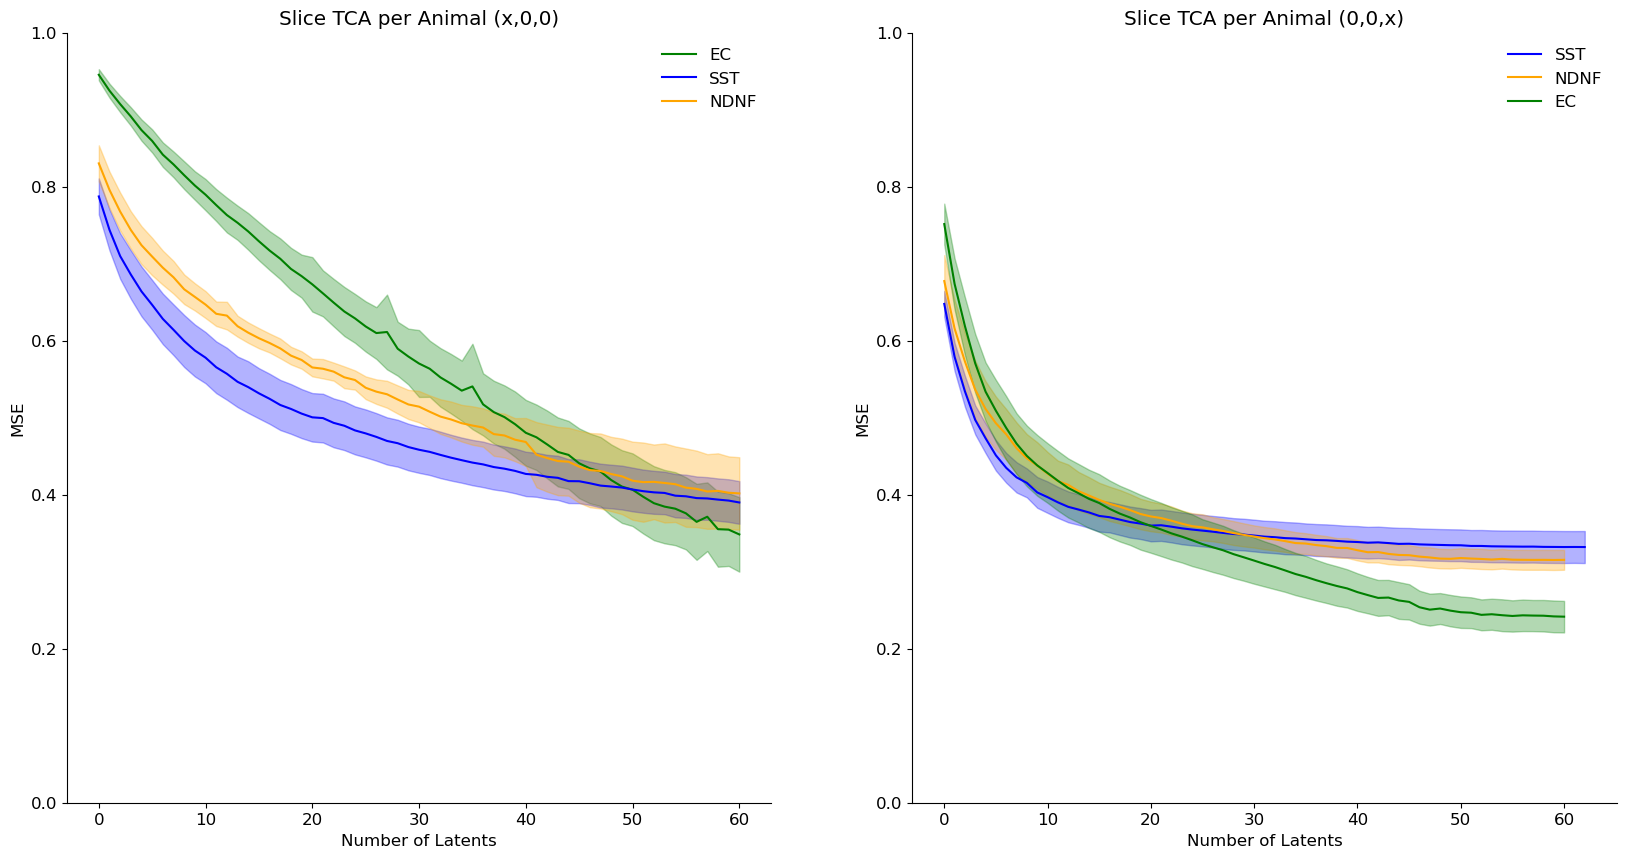

In [6]:

base_dir = r"C:\Users\Msfin\cloned_repositories\CA1-interneuron-GLM\datasets"
file_name_template = "loss_dict_SST_latent_2_22_animal{i}"
SST_mean_2_22, SST_sem_2_22 = get_data_by_animal_num(base_dir, file_name_template, animal_list=None, num_animals=10)

base_dir = r"C:\Users\Msfin\cloned_repositories\CA1-interneuron-GLM\datasets"
file_name_template = "loss_dict_SST_latent_22_42_animal{i}"
SST_mean_22_42, SST_sem_22_42 = get_data_by_animal_num(base_dir, file_name_template, animal_list=None, num_animals=10)

base_dir = r"C:\Users\Msfin\cloned_repositories\CA1-interneuron-GLM\datasets"
file_name_template = "loss_dict_SST_latent_42_62_animal{i}"
sst_mean_42_64, sst_sem_42_64 = get_data_by_animal_num(base_dir, file_name_template, animal_list=None, num_animals=10)


base_dir = r"C:\Users\Msfin\cloned_repositories\CA1-interneuron-GLM\datasets"
file_name_template = "NDNF_latent_loss_2_22_animal_{i}"
NDNF_mean_2_22, NDNF_sem_2_22 = get_data_by_animal_num(base_dir, file_name_template, animal_list=None, num_animals=4)

base_dir = r"C:\Users\Msfin\cloned_repositories\CA1-interneuron-GLM\datasets"
file_name_template = "loss_dict_NDNF_latent_22_42_animal{i}"
NDNF_mean_22_42, NDNF_sem_22_42 = get_data_by_animal_num(base_dir, file_name_template, animal_list=None, num_animals=4)

base_dir = r"C:\Users\Msfin\cloned_repositories\CA1-interneuron-GLM\datasets"
file_name_template = "loss_dict_NDNF_latent_42_62_animal{i}"
animal_list = [0, 2, 3]
NDNF_mean_42_62, NDNF_sem_42_62 = get_data_by_animal_num(base_dir, file_name_template, animal_list=animal_list, num_animals=None)



base_dir = r"C:\Users\Msfin\cloned_repositories\CA1-interneuron-GLM\datasets\EC_experiment"
EC_latent_means_2_22, EC_latent_sems_2_22 = cell_type_get_mean_sem(base_dir, start_num=2, end_num=22, cell_type="EC")

base_dir = r"C:\Users\Msfin\cloned_repositories\CA1-interneuron-GLM\datasets"
EC_latent_means_22_42, EC_latent_sems_22_42 = cell_type_get_mean_sem(base_dir, start_num=22, end_num=43, cell_type="EC")

base_dir = r"C:\Users\Msfin\cloned_repositories\CA1-interneuron-GLM\datasets\EC_experiment"
EC_latent_means_42_62, EC_latent_sems_42_62 = cell_type_get_mean_sem(base_dir, start_num=43, end_num=63, cell_type="EC")
    

concatenated_EC_means = np.concatenate([EC_latent_means_2_22, EC_latent_means_22_42, EC_latent_means_42_62])
concatenated_EC_sem = np.concatenate([EC_latent_sems_2_22, EC_latent_sems_22_42, EC_latent_sems_42_62])

concatenated_SST_means = np.concatenate([SST_mean_2_22, SST_mean_22_42[:-1], sst_mean_42_64[:-1]])
concatenated_SST_sem = np.concatenate([SST_sem_2_22, SST_sem_22_42[:-1], sst_sem_42_64[:-1]])

concatenated_NDNF_means = np.concatenate([NDNF_mean_2_22, NDNF_mean_22_42[:-1], NDNF_mean_42_62[:-1]])
concatenated_NDNF_sem = np.concatenate([NDNF_sem_2_22, NDNF_sem_22_42[:-1], NDNF_sem_42_62[:-1]])



##########################################




base_dir = r"C:\Users\Msfin\cloned_repositories\CA1-interneuron-GLM\datasets\EC_timebins_experiment"

# Holds lists of scalar losses for each latent number
latent_numbers = []

for i in range(2, 63):
    # Get all matching files
    pattern = os.path.join(base_dir, f"timebins_loss_dict_EC_latent_{i}_{i}_animal*.pkl")
    file_paths = sorted(glob.glob(pattern))

    # Store float values from each file
    loss_floats = []

    for path in file_paths:
        with open(path, "rb") as f:
            data = pickle.load(f)
            data = float(data)
            loss_floats.append(data)
            print(f"Loaded: {os.path.basename(path)}")

    latent_numbers.append(loss_floats)
    print(f"Total floats for latent {i}: {len(loss_floats)}\n")

EC_latent_means_timebins_62 = []
EC_latent_sems_timebins_62 = []

for i in latent_numbers:
    EC_latent_means_timebins_62.append(np.mean(i))
    EC_latent_sems_timebins_62.append(sem(i))

EC_latent_sems_timebins_62 = np.array(EC_latent_sems_timebins_62)








base_dir = r"C:\Users\Msfin\cloned_repositories\CA1-interneuron-GLM\datasets\EC_timebins_experiment"

# Holds lists of scalar losses for each latent number
latent_numbers = []

for i in range(2, 63):
    # Get all matching files
    pattern = os.path.join(base_dir, f"timebins_loss_dict_NDNF_latent_{i}_{i}_animal*.pkl")
    file_paths = sorted(glob.glob(pattern))

    # Store float values from each file
    loss_floats = []

    for path in file_paths:
        with open(path, "rb") as f:
            data = pickle.load(f)
            data = float(data)
            loss_floats.append(data)
            print(f"Loaded: {os.path.basename(path)}")

    latent_numbers.append(loss_floats)
    print(f"Total floats for latent {i}: {len(loss_floats)}\n")

NDNF_latent_means_timebins_62 = []
NDNF_latent_sems_timebins_62 = []

for i in latent_numbers:
    NDNF_latent_means_timebins_62.append(np.mean(i))
    NDNF_latent_sems_timebins_62.append(sem(i))
NDNF_latent_sems_timebins_62 = np.array(NDNF_latent_sems_timebins_62)







base_dir = r"C:\Users\Msfin\cloned_repositories\CA1-interneuron-GLM\datasets"

SST_list_2_24_timebins = []


for i in range(10):  # Assuming animals 0 to
    
    file_name = f"timebins_loss_dict_SST_latent_2_22_animal{i}.pkl"
    file_path = os.path.join(base_dir, file_name)

    # Load the pickle file
    with open(file_path, "rb") as f:
        animal = pickle.load(f)
        
    SST_list_2_24_timebins.append(animal)

SST_mean_2_24_timebins, SST_sem_2_24_timebins = get_mean_sem_loss2(SST_list_2_24_timebins)


base_dir = r"C:\Users\Msfin\cloned_repositories\CA1-interneuron-GLM\datasets"

SST_list_22_42_timebins = []


for i in range(10):  # Assuming animals 0 to
    
    file_name = f"timebins_loss_dict_SST_latent_22_42_animal{i}.pkl"
    file_path = os.path.join(base_dir, file_name)

    # Load the pickle file
    with open(file_path, "rb") as f:
        animal = pickle.load(f)
        
    SST_list_22_42_timebins.append(animal)

SST_mean_22_42_timebins, SST_sem_22_42_timebins = get_mean_sem_loss2(SST_list_22_42_timebins)


base_dir = r"C:\Users\Msfin\cloned_repositories\CA1-interneuron-GLM\datasets"

SST_list_42_62_timebins = []


for i in range(10):  # Assuming animals 0 to
    
    file_name = f"timebins_loss_dict_SST_latent_42_62_animal{i}.pkl"
    file_path = os.path.join(base_dir, file_name)

    # Load the pickle file
    with open(file_path, "rb") as f:
        animal = pickle.load(f)
        
    SST_list_42_62_timebins.append(animal)

SST_mean_42_62_timebins, SST_sem_42_62_timebins = get_mean_sem_loss2(SST_list_42_62_timebins)

SST_latent_mean_timebins_62 = np.concatenate([SST_mean_2_24_timebins, SST_mean_22_42_timebins, SST_mean_42_62_timebins])
SST_latent_sem_timebins_62 = np.concatenate([SST_sem_2_24_timebins, SST_sem_22_42_timebins, SST_sem_42_62_timebins])



##########################################

fig, axs = plt.subplots(1,2, figsize=(20,10))

axs[0].plot(concatenated_EC_means, label="EC", color='g')
axs[0].fill_between(range(len(concatenated_EC_means)),
                 concatenated_EC_means + concatenated_EC_sem,
                 concatenated_EC_means - concatenated_EC_sem,
                 alpha=0.3, color='g')
axs[0].plot(concatenated_SST_means, label="SST", color='b')
axs[0].fill_between(range(len(concatenated_SST_means)),
                 concatenated_SST_means + concatenated_SST_sem,
                 concatenated_SST_means - concatenated_SST_sem,
                 alpha=0.3, color='b')

axs[0].plot(concatenated_NDNF_means, label="NDNF", color='orange')
axs[0].fill_between(range(len(concatenated_NDNF_means)),
                 concatenated_NDNF_means + concatenated_NDNF_sem,
                 concatenated_NDNF_means - concatenated_NDNF_sem,
                 alpha=0.3, color='orange')
axs[0].legend()
axs[0].set_ylabel("MSE")
axs[0].set_ylim(0,1)
axs[0].set_ylabel("MSE")
axs[0].set_title("Slice TCA per Animal (x,0,0)")
axs[0].set_xlabel("Number of Latents")


axs[1].plot(SST_latent_mean_timebins_62, color='b', label='SST')
axs[1].fill_between(range(len(SST_latent_mean_timebins_62)),
                 SST_latent_mean_timebins_62 + SST_latent_sem_timebins_62,
                 SST_latent_mean_timebins_62 - SST_latent_sem_timebins_62,
                 alpha=0.3, color='b')
axs[1].plot(NDNF_latent_means_timebins_62, color='orange', label='NDNF')
axs[1].fill_between(range(len(NDNF_latent_means_timebins_62)),
                 NDNF_latent_means_timebins_62 + NDNF_latent_sems_timebins_62,
                 NDNF_latent_means_timebins_62 - NDNF_latent_sems_timebins_62,
                 alpha=0.3, color='orange')
axs[1].plot(EC_latent_means_timebins_62, color='g', label='EC')
axs[1].fill_between(range(len(EC_latent_means_timebins_62)),
                 EC_latent_means_timebins_62 + EC_latent_sems_timebins_62,
                 EC_latent_means_timebins_62 - EC_latent_sems_timebins_62,
                 alpha=0.3, color='g')
axs[1].legend()
axs[1].set_ylabel("MSE")
axs[1].set_title("Slice TCA per Animal (0,0,x)")
axs[1].set_ylim(0,1)
axs[1].set_xlabel("Number of Latents")

plt.show()

In [49]:
############# data loading -- contiguous cell 

mse_dir = r"C:\Users\Msfin\cloned_repositories\CA1-interneuron-GLM\datasets\cell_SST_model_ranks20_contig_x00_cells"
cell_SST_model_ranks20_contig_x00 = get_model_data_per_cell(mse_dir)

mse_dir = r"C:\Users\Msfin\cloned_repositories\CA1-interneuron-GLM\datasets\cell_EC_model_ranks20_contig_x00_cells"
cell_EC_model_ranks20_contig_x00 = get_model_data_per_cell(mse_dir)

mse_dir = r"C:\Users\Msfin\cloned_repositories\CA1-interneuron-GLM\datasets\cell_NDNF_model_ranks20_contig_x00_cells"
cell_NDNF_model_ranks20_contig_x00 = get_model_data_per_cell(mse_dir)

############## new NDNF
mse_dir = r"C:\Users\Msfin\cloned_repositories\CA1-interneuron-GLM\datasets\cell_new_NDNF_model_ranks20_contiguous_x00_cell"
cell_new_NDNF_model_ranks20_contiguous_x00_cell = get_model_data_per_cell(mse_dir)

Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 5 cells
    Animal 1: 15 cells
    Animal 2: 6 cells
    Animal 3: 4 cells
    Animal 4: 13 cells
    Animal 5: 13 cells
    Animal 6: 3 cells
    Animal 7: 3 cells
    Animal 8: 3 cells
    Animal 9: 10 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 192 cells
    Animal 1: 150 cells
    Animal 2: 154 cells
    Animal 3: 82 cells
    Animal 4: 74 cells
    Animal 5: 64 cells
    Animal 6: 76 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 14 cells
    Animal 1: 14 cells
    Animal 2: 6 cells
    Animal 3: 10 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 10 cells
    Animal 1: 8 cells
    Animal 2: 7 cells
    Animal 3: 7 cells
    Animal 4: 8 cells
    Animal 5: 9 cells
    Animal 6: 11 cells
    Animal 7: 6 cells
    Animal 8: 7 cells
    Animal 9: 10 cells
    Animal 10: 8 cells
    Animal 11: 7 cells
    Animal 12: 7 cells
    Animal 13: 8 cells
    Animal 14: 9 cells
    Animal 15: 11 cells
    Ani

In [127]:
fixed_cell_combined_NDNF_model_ranks20_contiguous_x00_cell = {20: {}}
fixed_cell_NDNF_model_ranks20_contiguous_x00_cell = {20: {}}

for idx, animal in enumerate(cell_new_NDNF_model_ranks20_contiguous_x00_cell[20]):
    if idx > 8:
        fixed_cell_combined_NDNF_model_ranks20_contiguous_x00_cell[20][animal] = cell_new_NDNF_model_ranks20_contiguous_x00_cell[20][animal]
        fixed_cell_NDNF_model_ranks20_contiguous_x00_cell[20][animal] = cell_new_NDNF_model_ranks20_contiguous_x00_cell[20][animal]
        
for animal in cell_NDNF_model_ranks20_contig_x00[20]:
    fixed_cell_combined_NDNF_model_ranks20_contiguous_x00_cell[20][f"old_{animal}"] = cell_NDNF_model_ranks20_contig_x00[20][animal]
    
fixed_cell_combined_NDNF_model_ranks20_contiguous_x00_cell[20].keys()

dict_keys([9, 10, 11, 12, 13, 14, 15, 16, 17, 'old_0', 'old_1', 'old_2', 'old_3'])

In [83]:
############ data loading contiguous animal 

mse_dir = r"C:\Users\Msfin\cloned_repositories\CA1-interneuron-GLM\datasets\animal_EC_model_ranks20_contig_x00"
animal_EC_model_ranks20_contig_x00 = get_model_data_per_animal2(mse_dir, cell_type="EC")
internals_per_animal_dict_EC_animal_x00_contig = preprocess_animal(animal_EC_model_ranks20_contig_x00, residual_activity_dict_EC, num_clusters=8, reassign_clusters=False, x00=True, umap=False, contiguous=True, ranks=20)

mse_dir = r"C:\Users\Msfin\cloned_repositories\CA1-interneuron-GLM\datasets\animal_SST_model_ranks20_contig_x00"
animal_SST_model_ranks20_contig_x00 = get_model_data_per_animal2(mse_dir, cell_type="EC")
internals_per_animal_dict_SST_animal_x00_contig = preprocess_animal(animal_SST_model_ranks20_contig_x00, residual_activity_dict_SST, num_clusters=8, reassign_clusters=False, x00=True, umap=False, contiguous=True, ranks=20)

mse_dir = r"C:\Users\Msfin\cloned_repositories\CA1-interneuron-GLM\datasets\animal_NDNF_model_ranks20_contig_x00"
animal_NDNF_model_ranks20_contig_x00 = get_model_data_per_animal2(mse_dir, cell_type="EC")
internals_per_animal_dict_NDNF_animal_x00_contig = preprocess_animal(animal_NDNF_model_ranks20_contig_x00, residual_activity_dict_NDNF_old, num_clusters=8, reassign_clusters=False, x00=True, umap=False, contiguous=True, ranks=20)

mse_dir = r"C:\Users\Msfin\cloned_repositories\CA1-interneuron-GLM\datasets\animal_new_ndnf_model_ranks20_contig_x00"
animal_new_ndnf_model_ranks20_contig_x00 = get_model_data_per_animal2(mse_dir, cell_type="EC")
internals_per_animal_dict_new_NDNF_animal_x00_contig = preprocess_animal(animal_new_ndnf_model_ranks20_contig_x00, residual_activity_dict_NDNF_new, num_clusters=8, reassign_clusters=False, x00=True, umap=False, contiguous=True, ranks=20)


Loaded MSEs for 1 rank(s).
  Rank 20: 7 animals loaded. IDs: [0, 1, 2, 3, 4, 5, 6]
Using breakpoint clustering (clusters = 1)
Using breakpoint clustering (clusters = 2)
Using breakpoint clustering (clusters = 3)
Using breakpoint clustering (clusters = 4)
Using breakpoint clustering (clusters = 5)
Using breakpoint clustering (clusters = 6)
Using breakpoint clustering (clusters = 7)
Processing cell 0...

clusters_chosen = 1
Before reassignment:
  Cluster 0: 78 trials
After reassignment:
  Cluster 0: 78 trials

clusters_chosen = 2
Before reassignment:
  Cluster 0: 40 trials
  Cluster 1: 38 trials
After reassignment:
  Cluster 0: 40 trials
  Cluster 1: 38 trials

clusters_chosen = 3
Before reassignment:
  Cluster 0: 40 trials
  Cluster 1: 15 trials
  Cluster 2: 23 trials
After reassignment:
  Cluster 0: 40 trials
  Cluster 1: 15 trials
  Cluster 2: 23 trials

clusters_chosen = 4
Before reassignment:
  Cluster 0: 40 trials
  Cluster 1: 5 trials
  Cluster 2: 10 trials
  Cluster 3: 23 trials



clusters_chosen = 7
Before reassignment:
  Cluster 0: 40 trials
  Cluster 1: 5 trials
  Cluster 2: 5 trials
  Cluster 3: 5 trials
  Cluster 4: 5 trials
  Cluster 5: 10 trials
  Cluster 6: 8 trials
After reassignment:
  Cluster 0: 40 trials
  Cluster 1: 5 trials
  Cluster 2: 5 trials
  Cluster 3: 5 trials
  Cluster 4: 5 trials
  Cluster 5: 10 trials
  Cluster 6: 8 trials
Processing cell 54...

clusters_chosen = 1
Before reassignment:
  Cluster 0: 78 trials
After reassignment:
  Cluster 0: 78 trials

clusters_chosen = 2
Before reassignment:
  Cluster 0: 40 trials
  Cluster 1: 38 trials
After reassignment:
  Cluster 0: 40 trials
  Cluster 1: 38 trials

clusters_chosen = 3
Before reassignment:
  Cluster 0: 40 trials
  Cluster 1: 15 trials
  Cluster 2: 23 trials
After reassignment:
  Cluster 0: 40 trials
  Cluster 1: 15 trials
  Cluster 2: 23 trials

clusters_chosen = 4
Before reassignment:
  Cluster 0: 40 trials
  Cluster 1: 5 trials
  Cluster 2: 10 trials
  Cluster 3: 23 trials
After rea


clusters_chosen = 7
Before reassignment:
  Cluster 0: 40 trials
  Cluster 1: 5 trials
  Cluster 2: 5 trials
  Cluster 3: 5 trials
  Cluster 4: 5 trials
  Cluster 5: 10 trials
  Cluster 6: 8 trials
After reassignment:
  Cluster 0: 40 trials
  Cluster 1: 5 trials
  Cluster 2: 5 trials
  Cluster 3: 5 trials
  Cluster 4: 5 trials
  Cluster 5: 10 trials
  Cluster 6: 8 trials
Processing cell 125...

clusters_chosen = 1
Before reassignment:
  Cluster 0: 78 trials
After reassignment:
  Cluster 0: 78 trials

clusters_chosen = 2
Before reassignment:
  Cluster 0: 40 trials
  Cluster 1: 38 trials
After reassignment:
  Cluster 0: 40 trials
  Cluster 1: 38 trials

clusters_chosen = 3
Before reassignment:
  Cluster 0: 40 trials
  Cluster 1: 15 trials
  Cluster 2: 23 trials
After reassignment:
  Cluster 0: 40 trials
  Cluster 1: 15 trials
  Cluster 2: 23 trials

clusters_chosen = 4
Before reassignment:
  Cluster 0: 40 trials
  Cluster 1: 5 trials
  Cluster 2: 10 trials
  Cluster 3: 23 trials
After re


clusters_chosen = 6
Before reassignment:
  Cluster 0: 5 trials
  Cluster 1: 10 trials
  Cluster 2: 20 trials
  Cluster 3: 20 trials
  Cluster 4: 5 trials
  Cluster 5: 6 trials
After reassignment:
  Cluster 0: 5 trials
  Cluster 1: 10 trials
  Cluster 2: 20 trials
  Cluster 3: 20 trials
  Cluster 4: 5 trials
  Cluster 5: 6 trials

clusters_chosen = 7
Before reassignment:
  Cluster 0: 5 trials
  Cluster 1: 10 trials
  Cluster 2: 15 trials
  Cluster 3: 5 trials
  Cluster 4: 20 trials
  Cluster 5: 5 trials
  Cluster 6: 6 trials
After reassignment:
  Cluster 0: 5 trials
  Cluster 1: 10 trials
  Cluster 2: 15 trials
  Cluster 3: 5 trials
  Cluster 4: 20 trials
  Cluster 5: 5 trials
  Cluster 6: 6 trials
Processing cell 3...

clusters_chosen = 1
Before reassignment:
  Cluster 0: 66 trials
After reassignment:
  Cluster 0: 66 trials

clusters_chosen = 2
Before reassignment:
  Cluster 0: 5 trials
  Cluster 1: 61 trials
After reassignment:
  Cluster 0: 5 trials
  Cluster 1: 61 trials

clusters_c


clusters_chosen = 4
Before reassignment:
  Cluster 0: 5 trials
  Cluster 1: 50 trials
  Cluster 2: 5 trials
  Cluster 3: 6 trials
After reassignment:
  Cluster 0: 5 trials
  Cluster 1: 50 trials
  Cluster 2: 5 trials
  Cluster 3: 6 trials

clusters_chosen = 5
Before reassignment:
  Cluster 0: 5 trials
  Cluster 1: 10 trials
  Cluster 2: 40 trials
  Cluster 3: 5 trials
  Cluster 4: 6 trials
After reassignment:
  Cluster 0: 5 trials
  Cluster 1: 10 trials
  Cluster 2: 40 trials
  Cluster 3: 5 trials
  Cluster 4: 6 trials

clusters_chosen = 6
Before reassignment:
  Cluster 0: 5 trials
  Cluster 1: 10 trials
  Cluster 2: 20 trials
  Cluster 3: 20 trials
  Cluster 4: 5 trials
  Cluster 5: 6 trials
After reassignment:
  Cluster 0: 5 trials
  Cluster 1: 10 trials
  Cluster 2: 20 trials
  Cluster 3: 20 trials
  Cluster 4: 5 trials
  Cluster 5: 6 trials

clusters_chosen = 7
Before reassignment:
  Cluster 0: 5 trials
  Cluster 1: 10 trials
  Cluster 2: 15 trials
  Cluster 3: 5 trials
  Cluster 

...

Using breakpoint clustering (clusters = 2)
Using breakpoint clustering (clusters = 3)
Using breakpoint clustering (clusters = 4)
Using breakpoint clustering (clusters = 5)
Using breakpoint clustering (clusters = 6)
Using breakpoint clustering (clusters = 7)
Processing cell 0...

clusters_chosen = 1
Before reassignment:
  Cluster 0: 390 trials
After reassignment:
  Cluster 0: 390 trials

clusters_chosen = 2
Before reassignment:
  Cluster 0: 5 trials
  Cluster 1: 385 trials
After reassignment:
  Cluster 0: 5 trials
  Cluster 1: 385 trials

clusters_chosen = 3
Before reassignment:
  Cluster 0: 5 trials
  Cluster 1: 145 trials
  Cluster 2: 240 trials
After reassignment:
  Cluster 0: 5 trials
  Cluster 1: 145 trials
  Cluster 2: 240 trials

clusters_chosen = 4
Before reassignment:
  Cluster 0: 5 trials
  Cluster 1: 60 trials
  Cluster 2: 85 trials
  Cluster 3: 240 trials
After reassignment:
  Cluster 0: 5 trials
  Cluster 1: 60 trials
  Cluster 2: 85 trials
  Cluster 3: 240 trials

clusters


clusters_chosen = 4
Before reassignment:
  Cluster 0: 5 trials
  Cluster 1: 60 trials
  Cluster 2: 85 trials
  Cluster 3: 240 trials
After reassignment:
  Cluster 0: 5 trials
  Cluster 1: 60 trials
  Cluster 2: 85 trials
  Cluster 3: 240 trials

clusters_chosen = 5
Before reassignment:
  Cluster 0: 5 trials
  Cluster 1: 60 trials
  Cluster 2: 85 trials
  Cluster 3: 150 trials
  Cluster 4: 90 trials
After reassignment:
  Cluster 0: 5 trials
  Cluster 1: 60 trials
  Cluster 2: 85 trials
  Cluster 3: 150 trials
  Cluster 4: 90 trials

clusters_chosen = 6
Before reassignment:
  Cluster 0: 5 trials
  Cluster 1: 60 trials
  Cluster 2: 35 trials
  Cluster 3: 50 trials
  Cluster 4: 150 trials
  Cluster 5: 90 trials
After reassignment:
  Cluster 0: 5 trials
  Cluster 1: 60 trials
  Cluster 2: 35 trials
  Cluster 3: 50 trials
  Cluster 4: 150 trials
  Cluster 5: 90 trials

clusters_chosen = 7
Before reassignment:
  Cluster 0: 5 trials
  Cluster 1: 60 trials
  Cluster 2: 35 trials
  Cluster 3: 1


clusters_chosen = 5
Before reassignment:
  Cluster 0: 10 trials
  Cluster 1: 5 trials
  Cluster 2: 35 trials
  Cluster 3: 65 trials
  Cluster 4: 47 trials
After reassignment:
  Cluster 0: 10 trials
  Cluster 1: 5 trials
  Cluster 2: 35 trials
  Cluster 3: 65 trials
  Cluster 4: 47 trials

clusters_chosen = 6
Before reassignment:
  Cluster 0: 10 trials
  Cluster 1: 5 trials
  Cluster 2: 35 trials
  Cluster 3: 40 trials
  Cluster 4: 25 trials
  Cluster 5: 47 trials
After reassignment:
  Cluster 0: 10 trials
  Cluster 1: 5 trials
  Cluster 2: 35 trials
  Cluster 3: 40 trials
  Cluster 4: 25 trials
  Cluster 5: 47 trials

clusters_chosen = 7
Before reassignment:
  Cluster 0: 10 trials
  Cluster 1: 5 trials
  Cluster 2: 35 trials
  Cluster 3: 25 trials
  Cluster 4: 15 trials
  Cluster 5: 25 trials
  Cluster 6: 47 trials
After reassignment:
  Cluster 0: 10 trials
  Cluster 1: 5 trials
  Cluster 2: 35 trials
  Cluster 3: 25 trials
  Cluster 4: 15 trials
  Cluster 5: 25 trials
  Cluster 6: 47

Using breakpoint clustering (clusters = 6)
Using breakpoint clustering (clusters = 7)
Processing cell 0...

clusters_chosen = 1
Before reassignment:
  Cluster 0: 122 trials
After reassignment:
  Cluster 0: 122 trials

clusters_chosen = 2
Before reassignment:
  Cluster 0: 80 trials
  Cluster 1: 42 trials
After reassignment:
  Cluster 0: 80 trials
  Cluster 1: 42 trials

clusters_chosen = 3
Before reassignment:
  Cluster 0: 45 trials
  Cluster 1: 35 trials
  Cluster 2: 42 trials
After reassignment:
  Cluster 0: 45 trials
  Cluster 1: 35 trials
  Cluster 2: 42 trials

clusters_chosen = 4
Before reassignment:
  Cluster 0: 35 trials
  Cluster 1: 10 trials
  Cluster 2: 35 trials
  Cluster 3: 42 trials
After reassignment:
  Cluster 0: 35 trials
  Cluster 1: 10 trials
  Cluster 2: 35 trials
  Cluster 3: 42 trials

clusters_chosen = 5
Before reassignment:
  Cluster 0: 30 trials
  Cluster 1: 5 trials
  Cluster 2: 10 trials
  Cluster 3: 35 trials
  Cluster 4: 42 trials
After reassignment:
  Clust

Using breakpoint clustering (clusters = 7)
Processing cell 0...

clusters_chosen = 1
Before reassignment:
  Cluster 0: 251 trials
After reassignment:
  Cluster 0: 251 trials

clusters_chosen = 2
Before reassignment:
  Cluster 0: 150 trials
  Cluster 1: 101 trials
After reassignment:
  Cluster 0: 150 trials
  Cluster 1: 101 trials

clusters_chosen = 3
Before reassignment:
  Cluster 0: 45 trials
  Cluster 1: 105 trials
  Cluster 2: 101 trials
After reassignment:
  Cluster 0: 45 trials
  Cluster 1: 105 trials
  Cluster 2: 101 trials

clusters_chosen = 4
Before reassignment:
  Cluster 0: 45 trials
  Cluster 1: 105 trials
  Cluster 2: 50 trials
  Cluster 3: 51 trials
After reassignment:
  Cluster 0: 45 trials
  Cluster 1: 105 trials
  Cluster 2: 50 trials
  Cluster 3: 51 trials

clusters_chosen = 5
Before reassignment:
  Cluster 0: 45 trials
  Cluster 1: 30 trials
  Cluster 2: 75 trials
  Cluster 3: 50 trials
  Cluster 4: 51 trials
After reassignment:
  Cluster 0: 45 trials
  Cluster 1: 30 

In [128]:
fixed_internals_animal_combined_NDNF_model_ranks20_contiguous_x00_cell = {}
fixed_internals_animal_NDNF_model_ranks20_contiguous_x00_cell = {}

for idx, animal in enumerate(internals_per_animal_dict_new_NDNF_animal_x00_contig):
    if idx > 8:
        fixed_internals_animal_combined_NDNF_model_ranks20_contiguous_x00_cell[animal] = internals_per_animal_dict_new_NDNF_animal_x00_contig[animal]
        fixed_internals_animal_NDNF_model_ranks20_contiguous_x00_cell[animal] = internals_per_animal_dict_new_NDNF_animal_x00_contig[animal]
        
for animal in internals_per_animal_dict_NDNF_animal_x00_contig:
    fixed_internals_animal_combined_NDNF_model_ranks20_contiguous_x00_cell[f"old_{animal}"] = internals_per_animal_dict_NDNF_animal_x00_contig[animal]
    
fixed_internals_animal_combined_NDNF_model_ranks20_contiguous_x00_cell.keys()

dict_keys([9, 10, 11, 12, 13, 14, 15, 16, 17, 'old_0', 'old_1', 'old_2', 'old_3'])

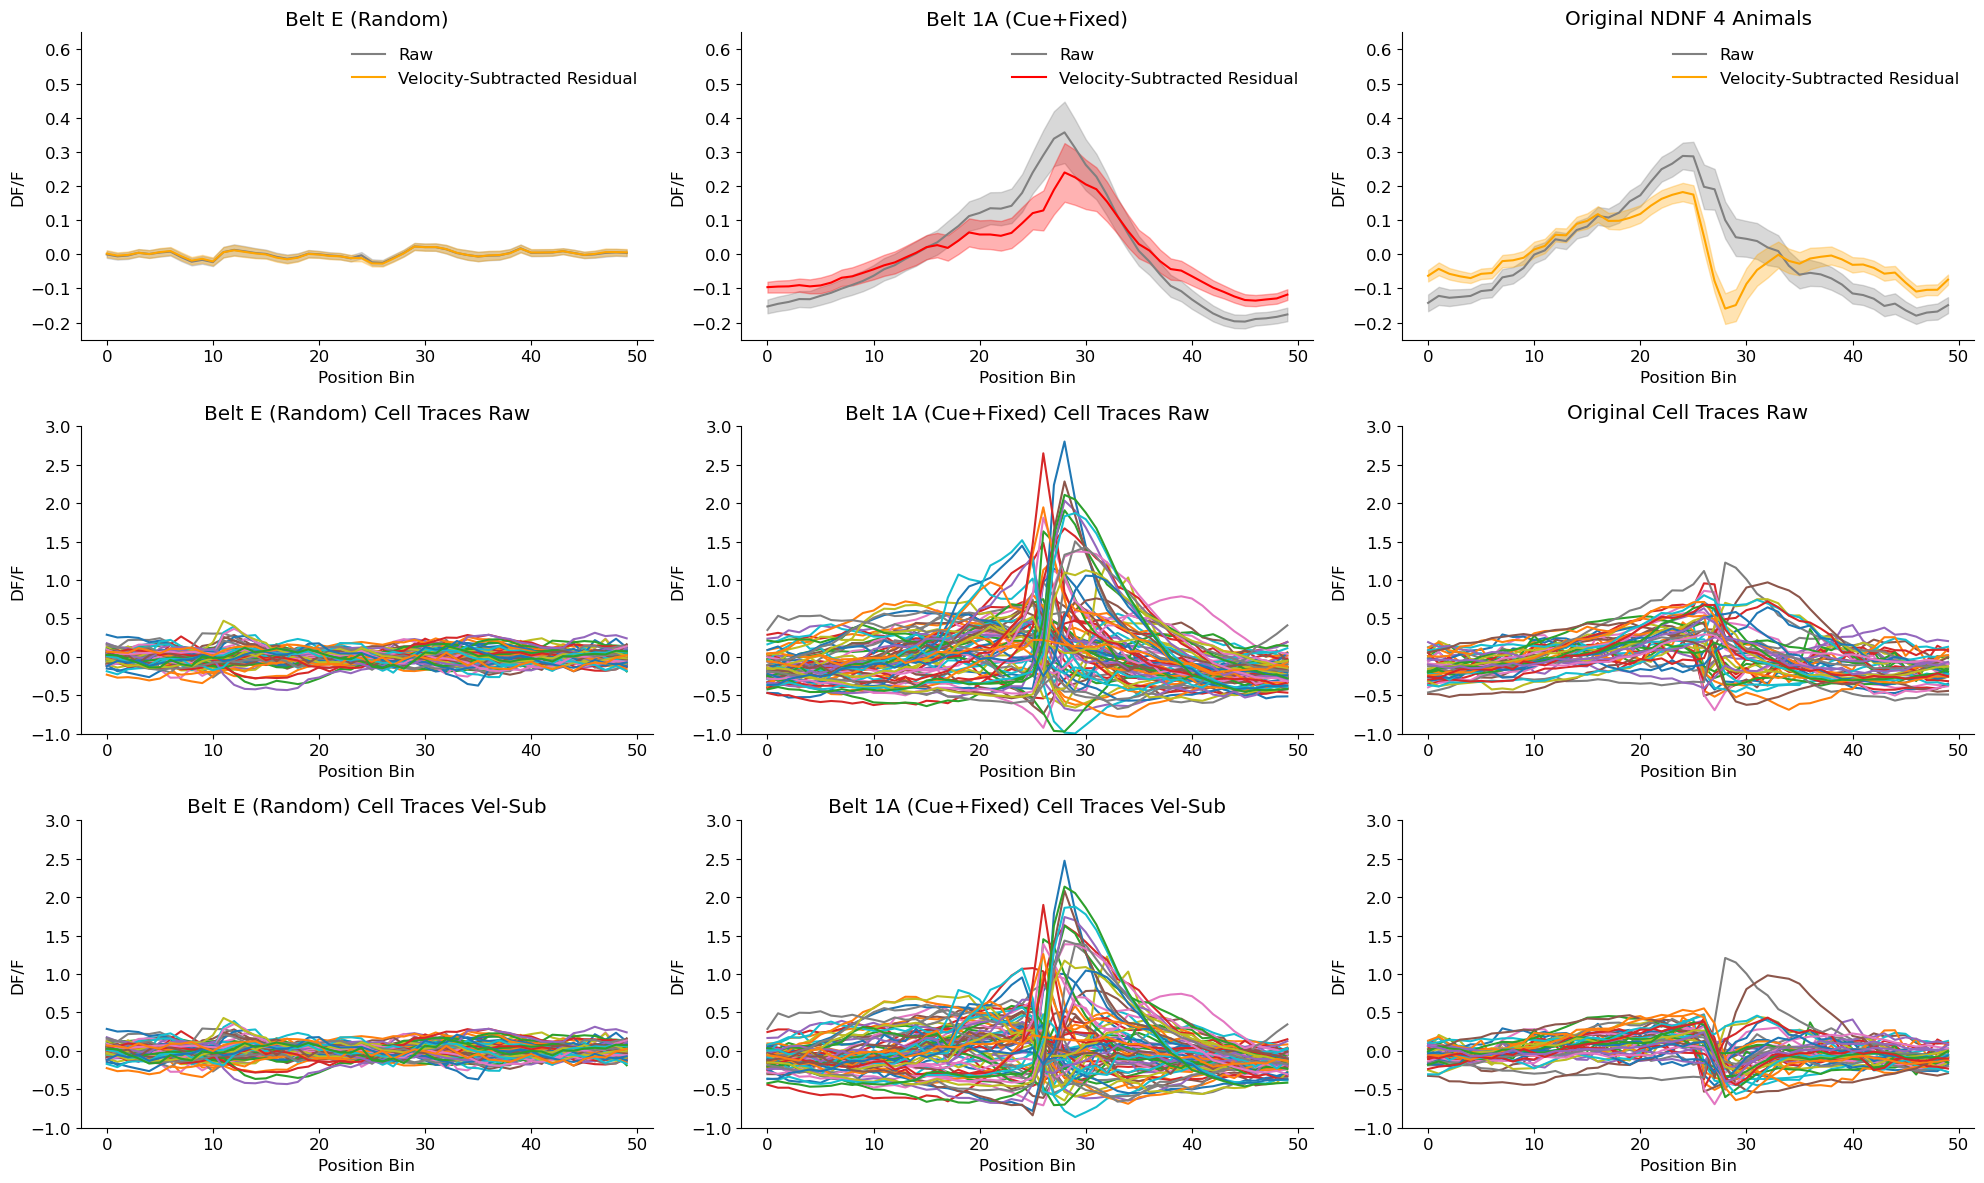

In [6]:
# get_plot_data(activity_dict, residual_activity_dict_NDNF_new, activity_dict_old_NDNF, residual_activity_dict_NDNF_old, animal_data=True)

get_plot_data(activity_dict, residual_activity_dict_NDNF_new, activity_dict_old_NDNF, residual_activity_dict_NDNF_old, animal_data=False)
      

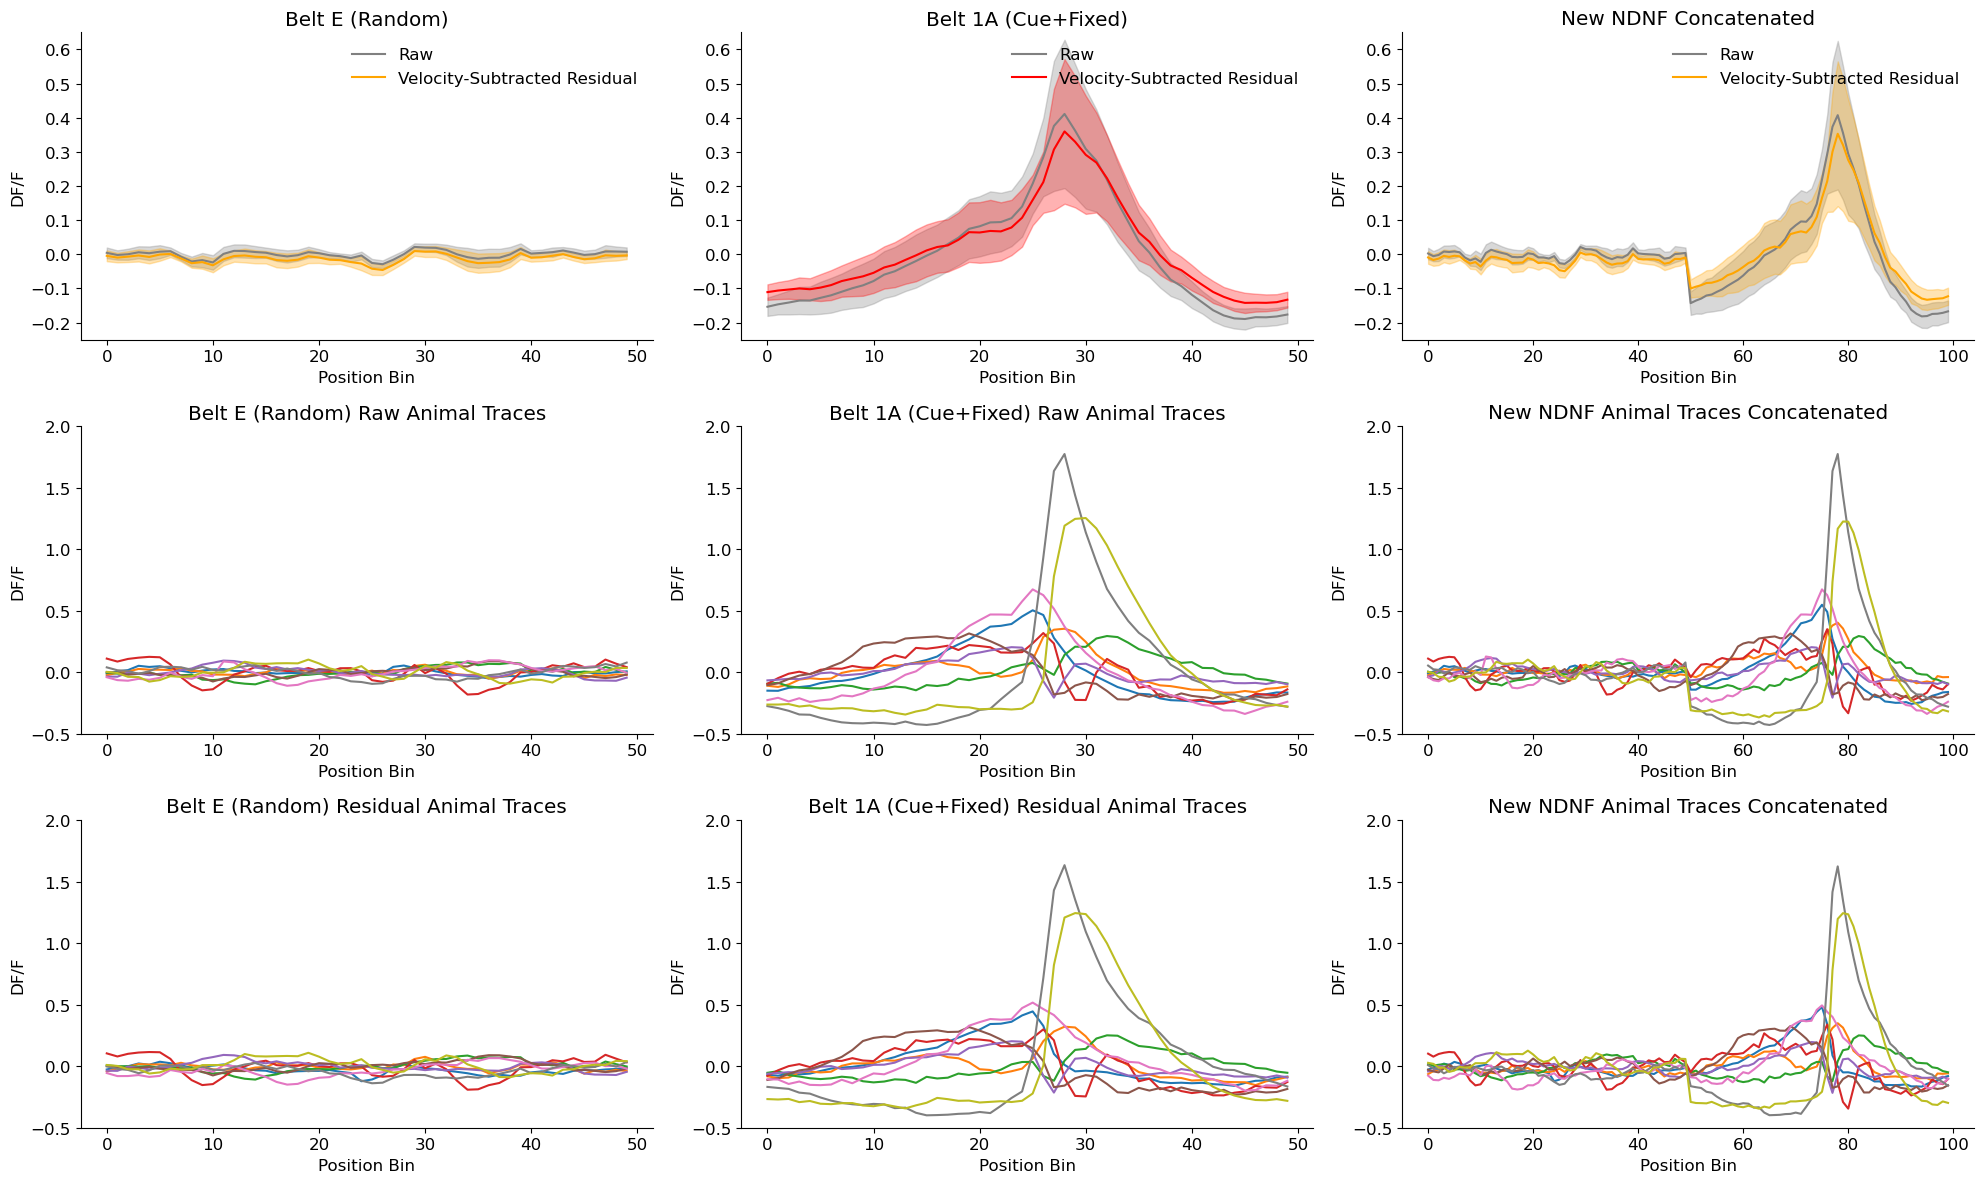

In [10]:
get_and_plot_concatenated_data(activity_dict, double_residual_activity_dict_NDNF_new, double_new_NDNF_activity_dict_100, double_residual_activity_dict_NDNF_new_100)    

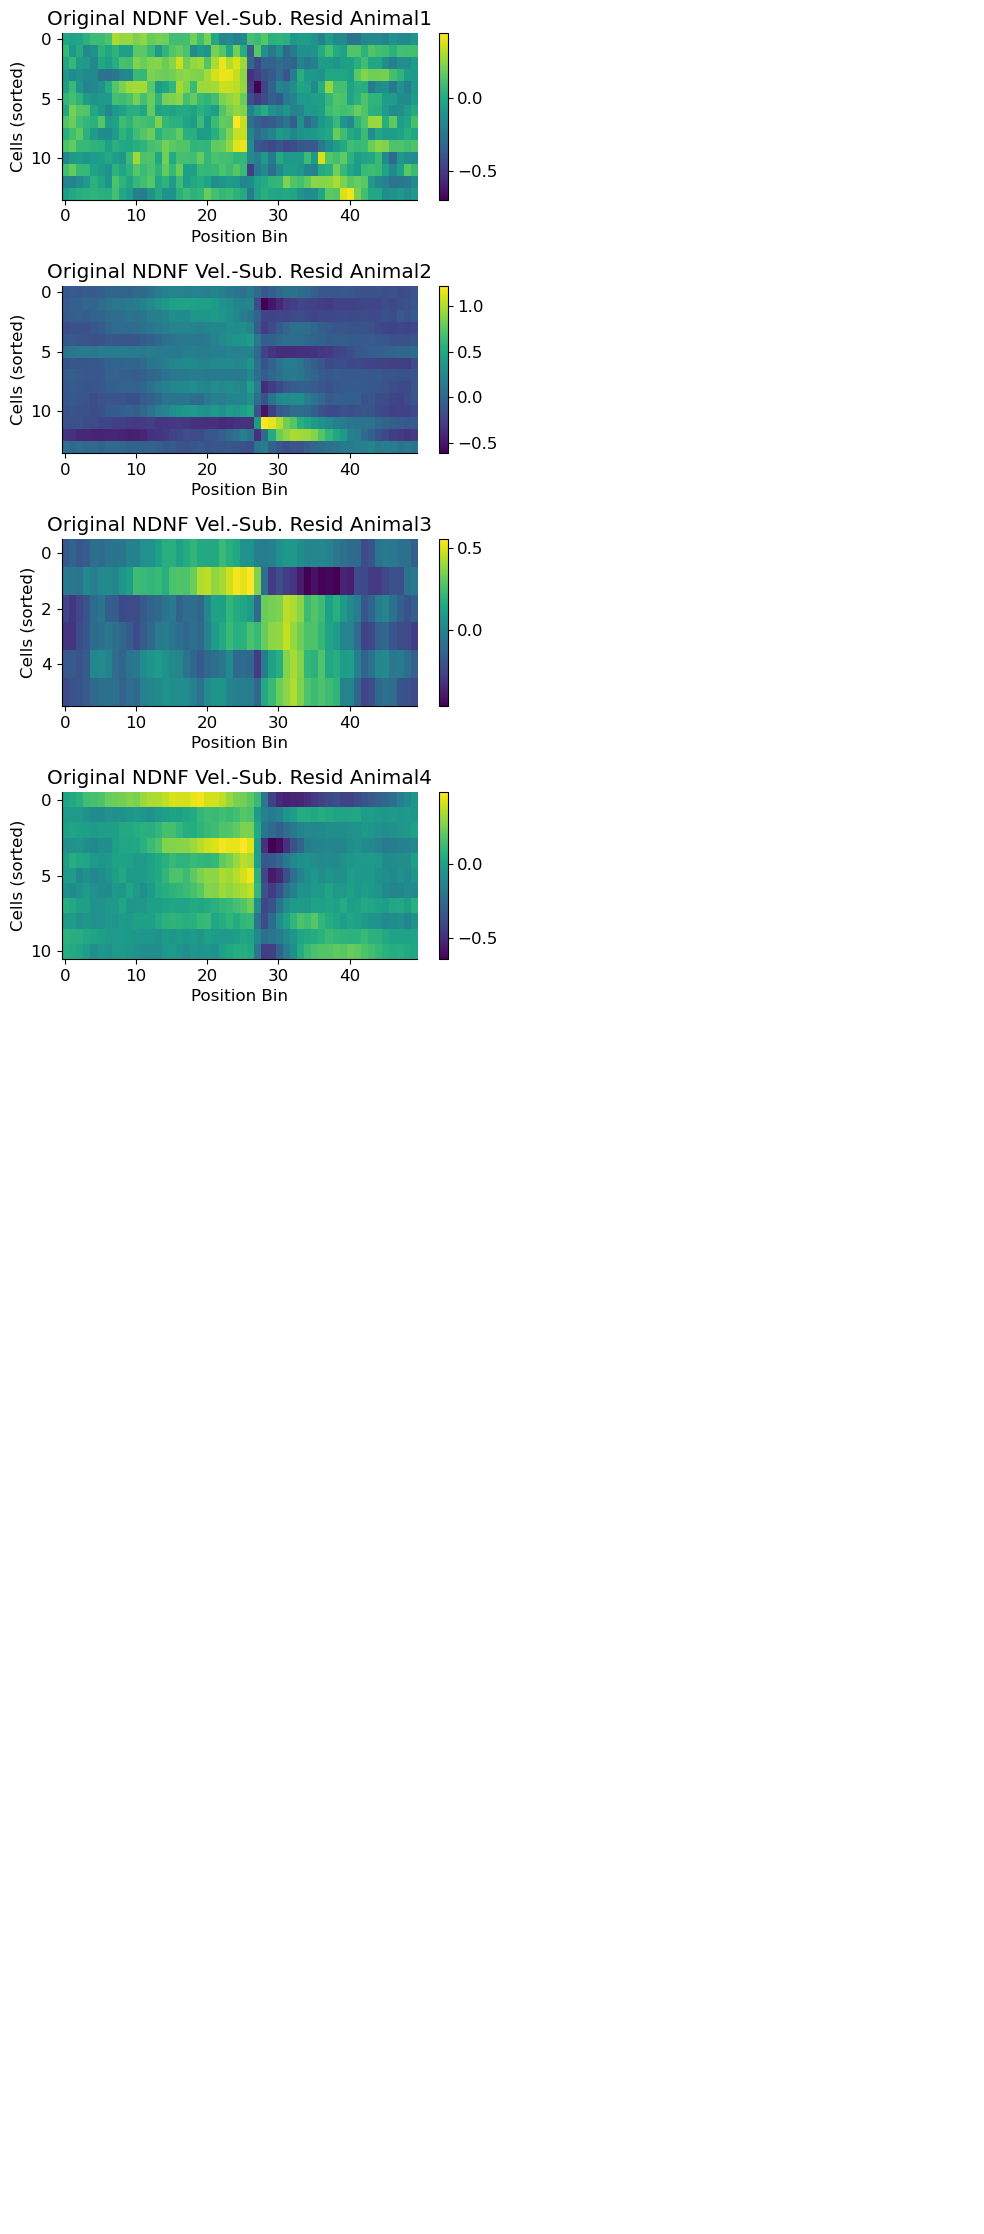

In [16]:
### run different lines of code to get different populations

# get_sorted_activity(activity_dict, title="New NDNF Raw")
# get_sorted_activity(residual_activity_dict_NDNF_new, title="New NDNF Vel.-Sub. Resid")
# get_sorted_activity(activity_dict_old_NDNF, title="Old NDNF Raw")
get_sorted_activity(residual_activity_dict_NDNF_old, title="Original NDNF Vel.-Sub. Resid")

In [12]:
########################### getting correlations 

In [13]:
correlation_vs_velocity_dict = {}
correlation_vs_velocity_dict_residuals = {}

for i in range(len(belt_A_list)):
    animal_A = belt_A_list[i]
    animal_B = belt_B_list[i]
    animal_A_residuals = belt_A_residuals_list[i]
    animal_B_residuals = belt_B_residuals_list[i]
    
    correlation_per_cell_dict = {}
    correlation_per_cell_dict_residuals = {}
    correlation_per_cell_list = []
    correlation_per_cell_list_residuals = []
    
    for cell in animal_A:
        
        cell_A_activity = animal_A[cell].flatten()
        cell_A_residual_activity = animal_A_residuals[cell].flatten()
        print(cell_A_activity.shape)
        cell_B_activity = animal_B[cell].flatten()
        cell_B_residual_activity = animal_B_residuals[cell].flatten()
        print(cell_B_activity.shape)
        
        velocity_early = filtered_factors_dict[f"animal_{i+1}"]["Velocity"].flatten()
        velocity_late = filtered_factors_dict[f"animal_{i+10}"]["Velocity"].flatten()
        print(velocity_early.shape)
        print(velocity_late.shape)
        
        r_value_vs_vel_A_residuals, _ = pearsonr(cell_A_residual_activity, velocity_early)
        r_value_vs_vel_B_residuals, _ = pearsonr(cell_B_residual_activity, velocity_late)
        
        r_value_vs_vel_A, _ = pearsonr(cell_A_activity, velocity_early)
        r_value_vs_vel_B, _ = pearsonr(cell_B_activity, velocity_late)
        
        r_value_list = [r_value_vs_vel_A, r_value_vs_vel_B]
        r_value_list_residuals = [r_value_vs_vel_A_residuals, r_value_vs_vel_B_residuals]
        
        correlation_per_cell_dict_residuals[cell] = r_value_list_residuals
        correlation_per_cell_dict[cell] = r_value_list
    
    correlation_vs_velocity_dict[i] = correlation_per_cell_dict
    correlation_vs_velocity_dict_residuals[i] = correlation_per_cell_dict_residuals
        
    

NameError: name 'belt_A_list' is not defined

In [ ]:
# plt.plot(correlation_vs_velocity_dict[0]["cell_5"])
length = len(correlation_vs_velocity_dict)
fig, axs = plt.subplots(1, length, figsize=(30,4))
for i in range(length):
    for cell in correlation_vs_velocity_dict[i]:
        axs[i].plot(correlation_vs_velocity_dict[i][cell])
        axs[i].set_ylim(-1, 1)
        axs[i].set_title(f"Animal {i} Raw DF/F Cells")
        axs[i].set_xticks(np.arange(2), ["Random Reward", "Fixed Reward"])
        axs[i].set_ylabel("Correlation to Velocity")
        
plt.tight_layout()
plt.show()

length = len(correlation_vs_velocity_dict_residuals)
fig, axs = plt.subplots(1, length, figsize=(30,4))
for i in range(length):
    for cell in correlation_vs_velocity_dict_residuals[i]:
        axs[i].plot(correlation_vs_velocity_dict_residuals[i][cell])
        axs[i].set_ylim(-1, 1)
        axs[i].set_title(f"Animal {i} Vel. Sub. Residuals")
        axs[i].set_xticks(np.arange(2), ["Random Reward", "Fixed Reward"])
        axs[i].set_ylabel("Correlation to Velocity")
        
plt.tight_layout()
plt.show()
    

In [ ]:
################## plotting the wondow 

plot_window(activity_dict, factors_dict)

In [ ]:
################ plotting the roll 
plot_roll(activity_dict, factors_dict)

In [ ]:

import os
import re
import pickle
from collections import OrderedDict

def get_model_data_per_cell(mse_dir):
    # Pattern matches: any cell type, with rank, animal, and cell ID
    pattern = re.compile(r"MSE_.*?_cell_latent_(\d+)_animal(\d+)_cell_id(\d+)\.pkl")

    # Temporary structure to store data unsorted
    temp_dict = {}

    for fname in os.listdir(mse_dir):
        if fname.endswith(".pkl"):
            match = pattern.match(fname)
            if match:
                rank = int(match.group(1))
                animal_id = int(match.group(2))
                cell_id = int(match.group(3))

                path = os.path.join(mse_dir, fname)
                with open(path, "rb") as f:
                    model_list = pickle.load(f)

                temp_dict.setdefault(rank, {}).setdefault(animal_id, {})[cell_id] = model_list
            else:
                print(f"[Skipping] Unexpected filename format: {fname}")

    # Now sort the outer and inner dictionaries by animal_id and cell_id
    rank_mse_dict = {}
    for rank in sorted(temp_dict):
        sorted_animals = OrderedDict()
        for animal_id in sorted(temp_dict[rank]):
            sorted_cells = OrderedDict()
            for cell_id in sorted(temp_dict[rank][animal_id]):
                sorted_cells[cell_id] = temp_dict[rank][animal_id][cell_id]
            sorted_animals[animal_id] = sorted_cells
        rank_mse_dict[rank] = sorted_animals

    # Summary printout
    print(f"Loaded MSEs for {len(rank_mse_dict)} rank(s).")
    for rank, animal_dict in rank_mse_dict.items():
        print(f"  Rank {rank}:")
        for animal_id, cell_dict in animal_dict.items():
            print(f"    Animal {animal_id}: {len(cell_dict)} cells")

    return rank_mse_dict


In [32]:
cell=1
print(cell_new_NDNF_model_ranks20_contiguous_x00_cell[20][0][cell][1][f"cell_{cell}"]["TCA_reconstructions_dict"]["clusters_chosen_3"].shape)

print(activity_dict["animal_1"]["cell_3"].T.shape)

(350, 50)
(350, 50)


In [6]:
def show_contiguous_internals(cell_models, animal_models, activity_dicts, cell_type="EC", cell_TCA=True, seperate_fixed_random=True, random_reward=False, combine_new_old=True):
    if cell_TCA:

        if cell_type == "NDNF_new":
            model = cell_models[0]
            
            if seperate_fixed_random:
            
                models_blank = {20:{}}
                models_fixed = {20:{}}

                for idx in model[20]:
                    if idx<9:
                        models_blank[20][idx] = model[20][idx]
                    else:
                        models_fixed[20][idx] = model[20][idx]

                if random_reward:
                    
                    new_activity = activity_dicts[0]
                    newer_activity = {}
                    for idx, animal in enumerate(new_activity):
                        if idx < 9:
                            newer_activity[animal] = new_activity[animal]

                    mean_list_NDNF_new_cell_x00, sem_list_NDNF_new_cell_x00 = get_contig_cluster_av(models_blank)
                    plot_average_activity_contig_kmeans(mean_list_NDNF_new_cell_x00, sem_list_NDNF_new_cell_x00, cell_type="NDNF", title="NDNF New Random Reward Cell SliceTCA x00")
                    cell_first_changepoints_list_new_NDNF, fraction_cell_first_changepoints_list_new_NDNF, cell_second_changepoints_list_new_NDNF, fraction_cell_second_changepoints_list_new_NDNF = get_changepoints(models_blank, newer_activity)
                    plot_changepoint_distribution(fraction_cell_first_changepoints_list_new_NDNF, fraction_cell_second_changepoints_list_new_NDNF, cell_type='New NDNF Random Reward')

                
                
                else:
                    if combine_new_old:
                        new_model = models_fixed # Start with NDNF_new
                        original = cell_models[1]                  # This is NDNF_original

                        for animal in original[20]:
                            new_model[20][f"new_{animal}"] = original[20][animal]

                        new_activity = activity_dicts[0]
                        original_activity = activity_dicts[1]
                        
                        
                        newer_activity = {}
                        for idx, animal in enumerate(new_activity):
                            if idx > 8:
                                newer_activity[animal] = new_activity[animal]
                            

                        for animal in original_activity:
                            newer_activity[f"new_{animal}"] = original_activity[animal]
                            
                    
                        mean_list_EC_cell_x00, sem_list_EC_cell_x00 = get_contig_cluster_av(new_model)
                        plot_average_activity_contig_kmeans(mean_list_EC_cell_x00, sem_list_EC_cell_x00, cell_type="NDNF", title="NDNF Combined New+Original Fixed Reward Cell SliceTCA x00")
                        cell_first_changepoints_list_EC, fraction_cell_first_changepoints_list_EC, cell_second_changepoints_list_EC, fraction_cell_second_changepoints_list_EC = get_changepoints(new_model, newer_activity)
                        plot_changepoint_distribution(fraction_cell_first_changepoints_list_EC, fraction_cell_second_changepoints_list_EC, cell_type="NDNF Fixed Reward New+Original")

                    else:
                        new_activity = activity_dicts[0]
                        newer_activity = {}
                        for idx, animal in enumerate(new_activity):
                            if idx > 8:
                                newer_activity[animal] = new_activity[animal]
                                
                        mean_list_NDNF_new_cell_x00, sem_list_NDNF_new_cell_x00 = get_contig_cluster_av(models_fixed)
                        plot_average_activity_contig_kmeans(mean_list_NDNF_new_cell_x00, sem_list_NDNF_new_cell_x00, cell_type="NDNF", title="NDNF New Cell SliceTCA x00")
                        cell_first_changepoints_list_new_NDNF, fraction_cell_first_changepoints_list_new_NDNF, cell_second_changepoints_list_new_NDNF, fraction_cell_second_changepoints_list_new_NDNF = get_changepoints(models_fixed, newer_activity)
                        plot_changepoint_distribution(fraction_cell_first_changepoints_list_new_NDNF, fraction_cell_second_changepoints_list_new_NDNF, cell_type='New NDNF Fixed Reward')

            else:
                mean_list_NDNF_new_cell_x00, sem_list_NDNF_new_cell_x00 = get_contig_cluster_av(models)
                plot_average_activity_contig_kmeans(mean_list_NDNF_new_cell_x00, sem_list_NDNF_new_cell_x00, cell_type="NDNF", title="NDNF New Cell SliceTCA x00")
                cell_first_changepoints_list_new_NDNF, fraction_cell_first_changepoints_list_new_NDNF, cell_second_changepoints_list_new_NDNF, fraction_cell_second_changepoints_list_new_NDNF = get_changepoints(model, activity_dicts[0])
                plot_changepoint_distribution(fraction_cell_first_changepoints_list_new_NDNF, fraction_cell_second_changepoints_list_new_NDNF, cell_type='New NDNF')
              
            
            
        elif cell_type == "NDNF_original":
            model = cell_models[1]
            mean_list_NDNF_old_cell_x00, sem_list_NDNF_old_cell_x00 = get_contig_cluster_av(model)
            plot_average_activity_contig_kmeans(mean_list_NDNF_old_cell_x00, sem_list_NDNF_old_cell_x00, cell_type="NDNF", title="NDNF Original Cell SliceTCA x00")
            cell_first_changepoints_list_old_NDNF, fraction_cell_first_changepoints_list_old_NDNF, cell_second_changepoints_list_old_NDNF, fraction_cell_second_changepoints_list_old_NDNF = get_changepoints(model, activity_dicts[1])
            plot_changepoint_distribution(fraction_cell_first_changepoints_list_old_NDNF, fraction_cell_second_changepoints_list_old_NDNF, cell_type="Original NDNF")

        elif cell_type == "SST":
            model = cell_models[2]
            mean_list_SST_cell_x00, sem_list_SST_cell_x00 = get_contig_cluster_av(model)
            plot_average_activity_contig_kmeans(mean_list_SST_cell_x00, sem_list_SST_cell_x00, cell_type="SST", title="SST Cell SliceTCA x00")
            cell_first_changepoints_list_SST, fraction_cell_first_changepoints_list_SST, cell_second_changepoints_list_SST, fraction_cell_second_changepoints_list_SST = get_changepoints(model, activity_dicts[2])
            plot_changepoint_distribution(fraction_cell_first_changepoints_list_SST, fraction_cell_second_changepoints_list_SST, cell_type="SST")

        elif cell_type == "EC":
            model = cell_models[3]
            mean_list_EC_cell_x00, sem_list_EC_cell_x00 = get_contig_cluster_av(model)
            plot_average_activity_contig_kmeans(mean_list_EC_cell_x00, sem_list_EC_cell_x00, cell_type="EC", title="EC Cell SliceTCA x00")
            cell_first_changepoints_list_EC, fraction_cell_first_changepoints_list_EC, cell_second_changepoints_list_EC, fraction_cell_second_changepoints_list_EC = get_changepoints(model, activity_dicts[3])
            plot_changepoint_distribution(fraction_cell_first_changepoints_list_EC, fraction_cell_second_changepoints_list_EC, cell_type="EC")
        
        elif cell_type == "NDNF_total":
            new_model = copy.deepcopy(cell_models[0])  # Start with NDNF_new
            original = cell_models[1]                  # This is NDNF_original

            for animal in original[20]:
                new_model[20][f"new_{animal}"] = original[20][animal]
                
            new_activity = activity_dicts[0]
            original_activity = activity_dicts[1]
            
            for animal in original_activity:
                new_activity[f"new_{animal}"] = original_activity[animal]
               
                
            mean_list_EC_cell_x00, sem_list_EC_cell_x00 = get_contig_cluster_av(new_model)
            plot_average_activity_contig_kmeans(mean_list_EC_cell_x00, sem_list_EC_cell_x00, cell_type="EC", title="EC Cell SliceTCA x00")
            cell_first_changepoints_list_EC, fraction_cell_first_changepoints_list_EC, cell_second_changepoints_list_EC, fraction_cell_second_changepoints_list_EC = get_changepoints(new_model, new_activity)
            plot_changepoint_distribution(fraction_cell_first_changepoints_list_EC, fraction_cell_second_changepoints_list_EC, cell_type="NDNF")
        


            ############ animal plotting ##############

    else:
        if cell_type == "NDNF_new":
            model = animal_models[0]
            
            if seperate_fixed_random:
            
                models_blank = {}
                models_fixed = {}

                for idx in model:
                    if idx<9:
                        models_blank[idx] = model[idx]
                    else:
                        models_fixed[idx] = model[idx]

                if random_reward:
                    
                    new_activity = activity_dicts[0]
                    newer_activity = {}
                    for idx, animal in enumerate(new_activity):
                        if idx < 9:
                            newer_activity[animal] = new_activity[animal]
                    
                    mean_list_new_NDNF_animal_x00, sem_list_EC_new_NDNF_animal_x00 = get_contig_cluster_av(models_blank, animal_TCA=True)
                    plot_average_activity_contig_kmeans(mean_list_new_NDNF_animal_x00, sem_list_EC_new_NDNF_animal_x00, cell_type="NDNF", title="New NDNF Animal SliceTCA x00")
                    animal_first_changepoints_list_new_NDNF, fraction_animal_first_changepoints_list_new_NDNF, animal_second_changepoints_list_new_NDNF, fraction_animal_second_changepoints_list_new_NDNF = get_changepoints(models_blank, newer_activity, animal_TCA=True)
                    plot_changepoint_distribution(fraction_animal_first_changepoints_list_new_NDNF, fraction_animal_second_changepoints_list_new_NDNF, cell_type="New NDNF Animal SliceTCA")

                else: 
                    if combine_new_old:
                        newer_model = models_fixed # Start with NDNF_new
                        originals = animal_models[1]                  # This is NDNF_original

                        for animal in originals:
                            newer_model[f"new_{animal}"] = originals[animal]


                        new_activity = activity_dicts[0]
                        original_activity = activity_dicts[1]
                        newer_activity = {}
                        for idx, animal in enumerate(new_activity):
                            if idx < 9:
                                newer_activity[animal] = new_activity[animal]
                                
                        for animal in original_activity:
                            newer_activity[f"new_{animal}"] = original_activity[animal]

                        mean_list_EC_cell_x00, sem_list_EC_cell_x00 = get_contig_cluster_av(newer_model, animal_TCA=True)
                        plot_average_activity_contig_kmeans(mean_list_EC_cell_x00, sem_list_EC_cell_x00, cell_type="NDNF", title="NDNF Combined New+Original Fixed Animal SliceTCA x00")
                        cell_first_changepoints_list_EC, fraction_cell_first_changepoints_list_EC, cell_second_changepoints_list_EC, fraction_cell_second_changepoints_list_EC = get_changepoints(newer_model, newer_activity, animal_TCA=True)
                        plot_changepoint_distribution(fraction_cell_first_changepoints_list_EC, fraction_cell_second_changepoints_list_EC, cell_type="NDNF New + Original Fixed Reward Animal SliceTCA")
                    
                    else:
                        new_activity = activity_dicts[0]
                        original_activity = activity_dicts[1]
                        newer_activity = {}
                        for idx, animal in enumerate(new_activity):
                            if idx < 9:
                                newer_activity[animal] = new_activity[animal]
                        
                        mean_list_new_NDNF_animal_x00, sem_list_EC_new_NDNF_animal_x00 = get_contig_cluster_av(models_fixed, animal_TCA=True)
                        plot_average_activity_contig_kmeans(mean_list_new_NDNF_animal_x00, sem_list_EC_new_NDNF_animal_x00, cell_type="NDNF", title="New NDNF Fixed Animal SliceTCA x00")
                        animal_first_changepoints_list_new_NDNF, fraction_animal_first_changepoints_list_new_NDNF, animal_second_changepoints_list_new_NDNF, fraction_animal_second_changepoints_list_new_NDNF = get_changepoints(models_fixed, newer_activity, animal_TCA=True)
                        plot_changepoint_distribution(fraction_animal_first_changepoints_list_new_NDNF, fraction_animal_second_changepoints_list_new_NDNF, cell_type="New NDNF Fixed Reward Animal SliceTCA")

            else:
                mean_list_new_NDNF_animal_x00, sem_list_EC_new_NDNF_animal_x00 = get_contig_cluster_av(model, animal_TCA=True)
                plot_average_activity_contig_kmeans(mean_list_new_NDNF_animal_x00, sem_list_EC_new_NDNF_animal_x00, cell_type="NDNF", title="New NDNF Animal SliceTCA x00")
                animal_first_changepoints_list_new_NDNF, fraction_animal_first_changepoints_list_new_NDNF, animal_second_changepoints_list_new_NDNF, fraction_animal_second_changepoints_list_new_NDNF = get_changepoints(model, activity_dicts[0], animal_TCA=True)
                plot_changepoint_distribution(fraction_animal_first_changepoints_list_new_NDNF, fraction_animal_second_changepoints_list_new_NDNF, cell_type="New NDNF Fixed+Random Animal SliceTCA")

            
            
            
        elif cell_type == "NDNF_original":
            model = animal_models[1]
            mean_list_old_NDNF_animal_x00, sem_list_EC_old_NDNF_animal_x00 = get_contig_cluster_av(animal_models[1], animal_TCA=True)
            plot_average_activity_contig_kmeans(mean_list_old_NDNF_animal_x00, sem_list_EC_old_NDNF_animal_x00, cell_type="NDNF", title="Original NDNF Animal SliceTCA x00")
            animal_first_changepoints_list_old_NDNF, fraction_animal_first_changepoints_list_old_NDNF, animal_second_changepoints_list_old_NDNF, fraction_animal_second_changepoints_list_old_NDNF = get_changepoints(model, activity_dicts[1], animal_TCA=True)
            plot_changepoint_distribution(fraction_animal_first_changepoints_list_old_NDNF, fraction_animal_second_changepoints_list_old_NDNF, cell_type="Original NDNF Animal SliceTCA")

        elif cell_type == "SST":
            model = animal_models[2]
            mean_list_SST_animal_x00, sem_list_EC_SST_animal_x00 = get_contig_cluster_av(animal_models[2], animal_TCA=True)
            plot_average_activity_contig_kmeans(mean_list_SST_animal_x00, sem_list_EC_SST_animal_x00, cell_type="SST", title="Original SST Animal SliceTCA x00")
            animal_first_changepoints_list_SST, fraction_animal_first_changepoints_list_SST, animal_second_changepoints_list_SST, fraction_animal_second_changepoints_list_SST = get_changepoints(model, activity_dicts[2], animal_TCA=True)
            plot_changepoint_distribution(fraction_animal_first_changepoints_list_SST, fraction_animal_second_changepoints_list_SST, cell_type="Original SST Animal SliceTCA")

        elif cell_type == "EC":
            model = animal_models[3]
            mean_list_EC_animal_x00, sem_list_EC_EC_animal_x00 = get_contig_cluster_av(animal_models[3], animal_TCA=True)
            plot_average_activity_contig_kmeans(mean_list_EC_animal_x00, sem_list_EC_EC_animal_x00, cell_type="EC", title="Original EC Animal SliceTCA x00")
            animal_first_changepoints_list_EC, fraction_animal_first_changepoints_list_EC, animal_second_changepoints_list_EC, fraction_animal_second_changepoints_list_EC = get_changepoints(model, activity_dicts[3], animal_TCA=True)
            plot_changepoint_distribution(fraction_animal_first_changepoints_list_EC, fraction_animal_second_changepoints_list_EC, cell_type="Original EC Animal SliceTCA")
        
#         elif cell_type == "NDNF_total":
#             newer_model = copy.deepcopy(animal_models[0])  # Start with NDNF_new
#             originals = animal_models[1]                  # This is NDNF_original

#             for animal in originals:
#                 newer_model[f"new_{animal}"] = originals[animal]
                
                
#             new_activity = activity_dicts[0]
#             original_activity = activity_dicts[1]
            
#             for animal in original_activity:
#                 new_activity[f"new_{animal}"] = original_activity[animal]
                
#             mean_list_EC_cell_x00, sem_list_EC_cell_x00 = get_contig_cluster_av(newer_model, animal_TCA=True)
#             plot_average_activity_contig_kmeans(mean_list_EC_cell_x00, sem_list_EC_cell_x00, cell_type="NDNF", title="NDNF Combined New+Old Animal SliceTCA x00")
#             cell_first_changepoints_list_EC, fraction_cell_first_changepoints_list_EC, cell_second_changepoints_list_EC, fraction_cell_second_changepoints_list_EC = get_changepoints(newer_model, new_activity, animal_TCA=True)
#             plot_changepoint_distribution(fraction_cell_first_changepoints_list_EC, fraction_cell_second_changepoints_list_EC, cell_type="NDNF")
        
        

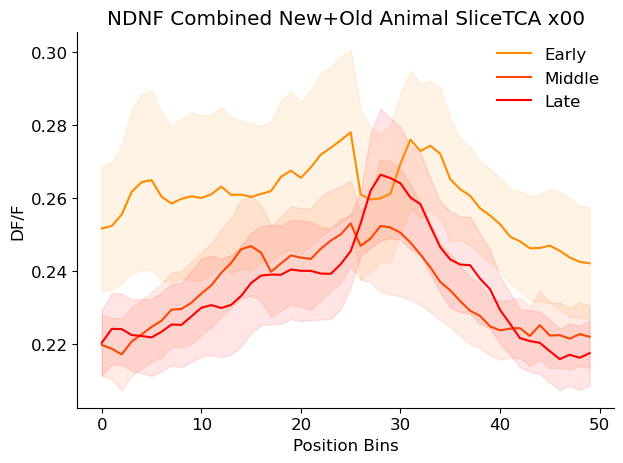

counts 66 we got problem 175 156
counts 67 we got problem 175 156
counts 68 we got problem 175 156
counts 69 we got problem 175 156
counts 70 we got problem 175 156
counts 71 we got problem 175 156
counts 72 we got problem 175 156
counts 87 we got problem 225 172
counts 88 we got problem 225 172
counts 89 we got problem 225 172
counts 90 we got problem 225 172
counts 91 we got problem 225 162
counts 92 we got problem 225 162
counts 93 we got problem 225 162
counts 94 we got problem 225 162
counts 95 we got problem 225 162
counts 96 we got problem 225 162
counts 97 we got problem 225 162
counts 98 we got problem 225 116
counts 99 we got problem 225 116
counts 100 we got problem 225 116
counts 113 we got problem 135 122
counts 114 we got problem 135 122
counts 115 we got problem 135 122
counts 116 we got problem 135 122
counts 117 we got problem 135 122


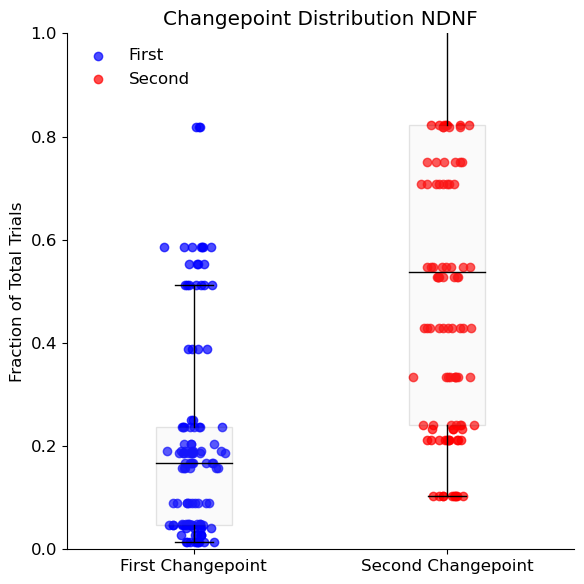

In [10]:
#options: NDNF_new, NDNF_original, NDNF_total, SST, EC


cell_models = [cell_new_NDNF_model_ranks20_contiguous_x00_cell, cell_NDNF_model_ranks20_contig_x00, cell_SST_model_ranks20_contig_x00, cell_EC_model_ranks20_contig_x00]
animal_models = [internals_per_animal_dict_new_NDNF_animal_x00_contig, internals_per_animal_dict_NDNF_animal_x00_contig, internals_per_animal_dict_SST_animal_x00_contig, internals_per_animal_dict_EC_animal_x00_contig]
activity_dicts = [activity_dict, activity_dict_old_NDNF, activity_dict_SST, activity_dict_EC]



#Cell SST
# show_contiguous_internals(cell_models, animal_models, activity_dicts, cell_type="SST")

#Cell EC
# show_contiguous_internals(cell_models, animal_models, activity_dicts, cell_type="EC")

#Cell new NDNF random reward
# show_contiguous_internals(cell_models, animal_models, activity_dicts, cell_type="NDNF_new", cell_TCA=True, seperate_fixed_random=True, random_reward=True, combine_new_old=False)

#Cell new NDNF fixed reward combined new and old 
# show_contiguous_internals(cell_models, animal_models, activity_dicts, cell_type="NDNF_new", cell_TCA=True, seperate_fixed_random=True, random_reward=False, combine_new_old=True)

#Cell new NDNF fixed reward combined just new 
# show_contiguous_internals(cell_models, animal_models, activity_dicts, cell_type="NDNF_new", cell_TCA=True, seperate_fixed_random=True, random_reward=False, combine_new_old=False)

#Cell new NDNF fixed reward combined just old
# show_contiguous_internals(cell_models, animal_models, activity_dicts, cell_type="NDNF_original")


#Animal SST
# show_contiguous_internals(cell_models, animal_models, activity_dicts, cell_type="SST", cell_TCA=False)

#Animal EC
# show_contiguous_internals(cell_models, animal_models, activity_dicts, cell_type="EC", cell_TCA=False)

#Animal new NDNF random reward
# show_contiguous_internals(cell_models, animal_models, activity_dicts, cell_type="NDNF_new", cell_TCA=False, seperate_fixed_random=True, random_reward=True, combine_new_old=False)

#Animal new NDNF fixed reward combined new and old 
show_contiguous_internals(cell_models, animal_models, activity_dicts, cell_type="NDNF_new", cell_TCA=False, seperate_fixed_random=True, random_reward=False, combine_new_old=True)

#Animal new NDNF fixed reward combined just new 
# show_contiguous_internals(cell_models, animal_models, activity_dicts, cell_type="NDNF_new", cell_TCA=False, seperate_fixed_random=True, random_reward=False, combine_new_old=False)

#Animal new NDNF fixed reward combined just old
# show_contiguous_internals(cell_models, animal_models, activity_dicts, cell_type="NDNF_original", cell_TCA=False)


In [ ]:
mse_dir = r"C:\Users\Msfin\cloned_repositories\CA1-interneuron-GLM\datasets\cell_SST_model_ranks20_reassign_umap_regkmean_x00_cell"
cell_SST_model_ranks20_kmeans_reassign_UMAP_x00 = get_model_data_per_cell(mse_dir)

mse_dir = r"C:\Users\Msfin\cloned_repositories\CA1-interneuron-GLM\datasets\cell_EC_model_ranks20_reassign_umap_regkmean_x00_cell"
cell_EC_model_ranks20_kmeans_reassign_UMAP_x00 = get_model_data_per_cell(mse_dir)

mse_dir = r"C:\Users\Msfin\cloned_repositories\CA1-interneuron-GLM\datasets\cell_NDNF_model_ranks20_reassign_umap_regkmean_x00_cell"
cell_NDNF_model_ranks20_kmeans_reassign_UMAP_x00 = get_model_data_per_cell(mse_dir)

In [ ]:
trial_nums_list_A = []
trial_nums_list_B = []

for ids, animal in enumerate(activity_dict):
    trail_num = activity_dict[animal]["cell_2"].shape[1]
    if ids<9:
        trial_nums_list_A.append(trail_num) 
    else:
        trial_nums_list_B.append(trail_num) 
        
real_trial_length = []
for i in range(9):
    t_num_A = trial_nums_list_A[i]
    t_num_B = trial_nums_list_B[i]
    nums = [t_num_A, t_num_B]
    
    min_num = np.min(nums)
    real_trial_length.append(min_num)
    

real_trial_length = np.array(real_trial_length)


double_real_trial_length = np.concatenate([real_trial_length, real_trial_length])
    
animal_list_A = []
animal_list_B = []

for idx, animal in enumerate(activity_dict):
    cell_list_A = []
    cell_list_B = []
    for cell in activity_dict[animal]:
        
        neuron_activity = activity_dict[animal][cell]
        trialss = double_real_trial_length[idx]
        neuron_activity_truncated = neuron_activity[:,:trialss]
        print(neuron_activity_truncated.shape)
        
        flat_activity = neuron_activity_truncated.flatten()
        if idx<9:
            cell_list_A.append(flat_activity)
        else:
            cell_list_B.append(flat_activity)
    if idx<9:
        animal_list_A.append(cell_list_A)
    else:
        animal_list_B.append(cell_list_B)
            
print(len(animal_list_A[2]))
print(animal_list_B[2])

for j in animal_list_A:
    
    combined_cell_activity_dict = {}
    
    animal_A = animal_list_A[j]
    animal_B = animal_list_B[j]
    for k in range(len(animal_A)):
        
        double_track_activity = np.concatenate([real_trial_length, real_trial_length])
        

#########333 plotting a random cell and its random rewards 

cell_activity_flat = activity_dict["animal_1"]["cell_2"].flatten()
cell_activity = activity_dict["animal_1"]["cell_2"]
reward_data_flat = factors_dict["animal_1"]["Reward_loc"].flatten()
reward_data = factors_dict["animal_1"]["Reward_loc"]

fig, axs = plt.subplots(2, 2, figsize=(15,10))

axs[0, 0].plot(cell_activity_flat[:1000])
axs[0, 0].set_title("Cell Activity")
axs[1, 0].plot(reward_data_flat[:1000])
axs[1, 0].set_title("Reward Locations")

axs[0, 1].imshow(cell_activity.T, aspect='auto')
axs[0, 1].set_title("Cell Activity")
axs[1, 1].imshow(reward_data.T, aspect='auto')
axs[1, 1].set_title("Reward Locations")




In [ ]:
############ getting the probability window 

def sliding_window_probabilities(labels, window_size=10):
    labels = np.array(labels)
    n = len(labels)
    probs_0 = []
    probs_1 = []
    probs_2 = []

    for start in range(n - window_size + 1):
        window = labels[start:start+window_size]
        counts = np.bincount(window, minlength=3)  
        probs = counts / window_size
        
        probs_0.append(probs[0])
        probs_1.append(probs[1])
        probs_2.append(probs[2])

    return np.array(probs_0), np.array(probs_1), np.array(probs_2)

# Example usage
probs_0, probs_1, probs_2 = sliding_window_probabilities(labels, window_size=10)

plt.figure(figsize=(12,6))
x = np.arange(len(probs_0))
plt.plot(x, probs_0, label="0's", color='red')
plt.plot(x, probs_1, label="1's", color='blue')
plt.plot(x, probs_2, label="2's", color='green')
plt.xlabel("Position along array (window center)")
plt.ylabel("Probability")
plt.title(f"Sliding Window Probabilities (Window size={window_size})")
plt.legend()
plt.tight_layout()
plt.show()


############### clusters can be of size 2

mse_dir = r"C:\Users\Msfin\cloned_repositories\CA1-interneuron-GLM\datasets\cell_SST_model_ranks20_reassign_regkmean_x00_cell"
new_cell_SST_model_ranks20_kmeans_reassign_x00 = get_model_data_per_cell(mse_dir)

mse_dir = r"C:\Users\Msfin\cloned_repositories\CA1-interneuron-GLM\datasets\cell_EC_model_ranks20_reassign_regkmean_x00_cell"
new_cell_EC_model_ranks20_kmeans_reassign_x00 = get_model_data_per_cell(mse_dir)

mse_dir = r"C:\Users\Msfin\cloned_repositories\CA1-interneuron-GLM\datasets\cell_NDNF_model_ranks20_reassign_regkmean_x00_cell"
new_cell_NDNF_model_ranks20_kmeans_reassign_x00 = get_model_data_per_cell(mse_dir)

In [4]:
################ clusters must be of size 3+

mse_dir = r"C:\Users\Msfin\cloned_repositories\CA1-interneuron-GLM\datasets\testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell"
testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell = get_model_data_per_cell(mse_dir)

mse_dir = r"C:\Users\Msfin\cloned_repositories\CA1-interneuron-GLM\datasets\testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell"
testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell = get_model_data_per_cell(mse_dir)

mse_dir = r"C:\Users\Msfin\cloned_repositories\CA1-interneuron-GLM\datasets\testing_cell_OLD_NDNF_model_ranks20_reassign_regkmean_x00_cell"
testing_cell_OLD_NDNF_model_ranks20_reassign_regkmean_x00_cell = get_model_data_per_cell(mse_dir)


Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 5 cells
    Animal 1: 15 cells
    Animal 2: 6 cells
    Animal 3: 4 cells
    Animal 4: 13 cells
    Animal 5: 13 cells
    Animal 6: 3 cells
    Animal 7: 3 cells
    Animal 8: 3 cells
    Animal 9: 10 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 192 cells
    Animal 1: 150 cells
    Animal 2: 154 cells
    Animal 3: 82 cells
    Animal 4: 74 cells
    Animal 5: 64 cells
    Animal 6: 76 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 14 cells
    Animal 1: 14 cells
    Animal 2: 6 cells
    Animal 3: 10 cells


In [5]:
mse_dir = r"C:\Users\Msfin\cloned_repositories\CA1-interneuron-GLM\datasets\testing_cell_super_new_NDNF_model_ranks20_reassign_regkmean_x00_cell"
testing_cell_super_new_NDNF_model_ranks20_reassign_regkmean_x00_cell = get_model_data_per_cell(mse_dir)

Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 10 cells
    Animal 1: 8 cells
    Animal 2: 7 cells
    Animal 3: 7 cells
    Animal 4: 8 cells
    Animal 5: 9 cells
    Animal 6: 11 cells
    Animal 7: 6 cells
    Animal 8: 7 cells
    Animal 9: 10 cells
    Animal 10: 8 cells
    Animal 11: 7 cells
    Animal 12: 7 cells
    Animal 13: 8 cells
    Animal 14: 9 cells
    Animal 15: 11 cells
    Animal 16: 6 cells
    Animal 17: 7 cells


✅ Found first singleton cluster for 3 cells
✅ Found first singleton cluster for 0 cells
✅ Found first singleton cluster for 112 cells


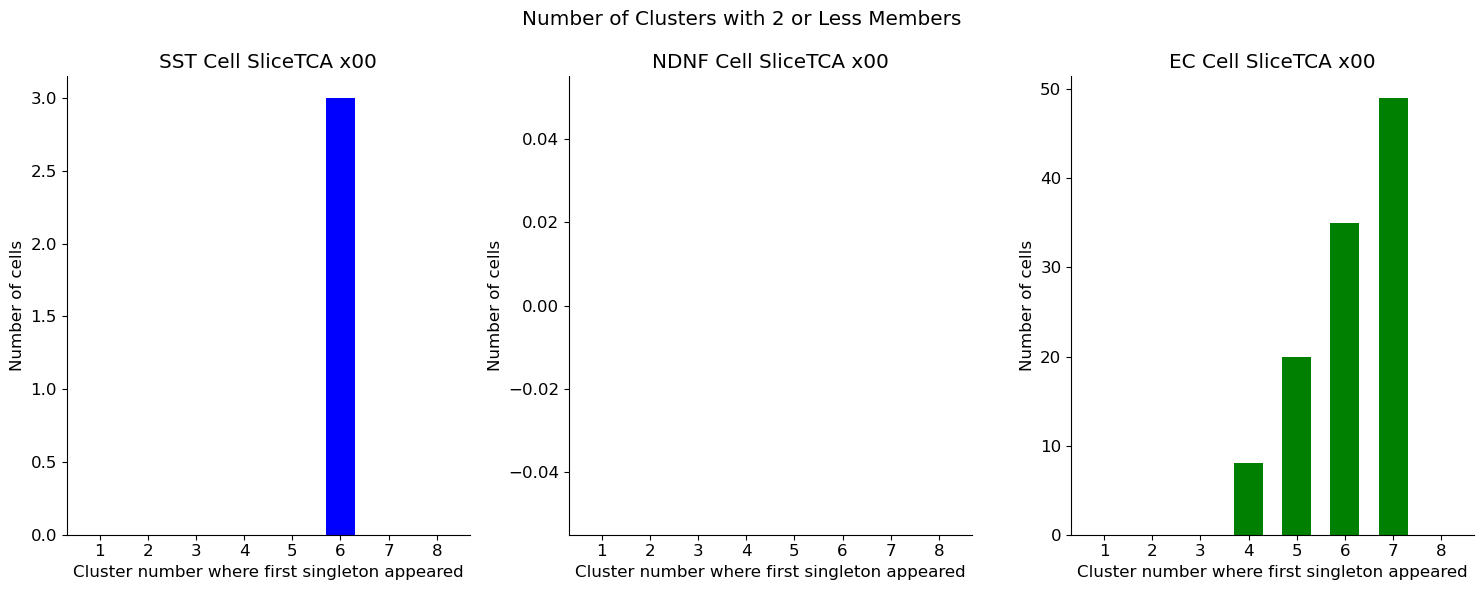

In [52]:
def get_counts_of_first_kmeans_failure(model_dict, rank=20, cluster_range=range(1, 9)):
    cluster_of_first_singletons_dict = {}
    cluster_count_dict = {k: 0 for k in cluster_range}  # initialize 1–8 with 0s

    if rank not in model_dict:
        return cluster_of_first_singletons_dict, cluster_count_dict

    for animal in model_dict[rank]:
        for cell in model_dict[rank][animal]:
            labels_dict = model_dict[rank][animal][cell][1][f"cell_{cell}"]['labels_dict']
            found_singleton = False

            for idx, clusters_chosen in enumerate(labels_dict):
                labels = labels_dict[clusters_chosen]
                unique_vals, counts = np.unique(labels, return_counts=True)
                singleton_labels = unique_vals[counts == 1]

                if len(singleton_labels) > 0 and not found_singleton:
                    cluster_number = int(clusters_chosen.split('_')[-1])
                    print(f"Warning: {len(singleton_labels)} singleton(s) found in {clusters_chosen} for {animal}, cell {cell}")

                    if animal not in cluster_of_first_singletons_dict:
                        cluster_of_first_singletons_dict[animal] = {}
                    cluster_of_first_singletons_dict[animal][cell] = cluster_number

                    if cluster_number in cluster_count_dict:
                        cluster_count_dict[cluster_number] += 1

                    found_singleton = True
                    break

    print(f"✅ Found first singleton cluster for {sum(len(c) for c in cluster_of_first_singletons_dict.values())} cells")
    return cluster_of_first_singletons_dict, cluster_count_dict

                
                
def plot_histogram_from_counts(cluster_count_list):
    
    cluster_count_dict_SST = cluster_count_list[0]
    cluster_count_dict_NDNF = cluster_count_list[1]
    cluster_count_dict_EC = cluster_count_list[2]
    
    fig, axs = plt.subplots(1, 3, figsize=(15,6))
    
    plt.suptitle("Number of Clusters with 2 or Less Members")

    cluster_numbers_SST = sorted(cluster_count_dict_SST.keys())
    counts_SST = [cluster_count_dict_SST[k] for k in cluster_numbers_SST]

    axs[0].bar(cluster_numbers_SST, counts_SST, align='center', width=0.6, color='b')
    axs[0].set_xlabel('Cluster number where first singleton appeared')
    axs[0].set_ylabel('Number of cells')
    axs[0].set_title("SST Cell SliceTCA x00")
    axs[0].set_xticks(cluster_numbers_SST)
    
    cluster_numbers_NDNF = sorted(cluster_count_dict_NDNF.keys())
    counts_NDNF = [cluster_count_dict_NDNF[k] for k in cluster_numbers_NDNF]

    axs[1].bar(cluster_numbers_NDNF, counts_NDNF, align='center', width=0.6, color='orange')
    axs[1].set_xlabel('Cluster number where first singleton appeared')
    axs[1].set_ylabel('Number of cells')
    axs[1].set_title("NDNF Cell SliceTCA x00")
    axs[1].set_xticks(cluster_numbers_NDNF)
    
    cluster_numbers_EC = sorted(cluster_count_dict_EC.keys())
    counts_EC = [cluster_count_dict_EC[k] for k in cluster_numbers_EC]

    axs[2].bar(cluster_numbers_EC, counts_EC, align='center', width=0.6, color='g')
    axs[2].set_xlabel('Cluster number where first singleton appeared')
    axs[2].set_ylabel('Number of cells')
    axs[2].set_title("EC Cell SliceTCA x00")
    axs[2].set_xticks(cluster_numbers_EC)

    plt.tight_layout()
    
    plt.show()



dict_sst, counts_sst = get_counts_of_first_kmeans_failure(testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell)
############## using the new NDNF 
dict_ndnf, counts_ndnf = get_counts_of_first_kmeans_failure(testing_cell_super_new_NDNF_model_ranks20_reassign_regkmean_x00_cell)
dict_ec, counts_ec = get_counts_of_first_kmeans_failure(testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell)

counts_list = [counts_sst, counts_ndnf, counts_ec]
plot_histogram_from_counts(counts_list)

In [148]:
import numpy as np

def sliding_window_probabilities(labels, window_size=10):
    labels = np.array(labels)
    unique_labels = np.unique(labels)
    n = len(labels)

    # Dictionary to hold probability lists per label
    label_probs = {label: [] for label in unique_labels}

    for start in range(n - window_size + 1):
        window = labels[start:start + window_size]
        counts = np.bincount(window, minlength=unique_labels.max() + 1)
        probs = counts / window_size

        for label in unique_labels:
            label_probs[label].append(probs[label])

    # Convert lists to arrays
    for label in label_probs:
        label_probs[label] = np.array(label_probs[label])

    return label_probs


In [193]:
# MSE_array_min_max, difference_MSE_array_min_max, elbow_kmeans, cluster_range, silhouette_scores, max_silhouette_reg = compare_umap_kmeans(testing_cell_super_new_NDNF_model_ranks20_reassign_regkmean_x00_cell, animal=1, cell=1)
# plot_kmeans_clusters_silhouette(MSE_array_min_max, difference_MSE_array_min_max, elbow_kmeans, cluster_range, silhouette_scores, max_silhouette_reg)
# print(f"elbow_kmeans {elbow_kmeans}")


# labels_dict = testing_cell_super_new_NDNF_model_ranks20_reassign_regkmean_x00_cell[20][animal][cell][1][f"cell_{cell}"]["labels_dict"]

# for idx, clusters_chosen in enumerate(labels_dict):
#     cluster_of_interest = 3
#     if idx == cluster_of_interest:
#         proper_labels = labels_dict[clusters_chosen]
#         label_probs = sliding_window_probabilities(proper_labels, window_size=10)
#         print(label_probs)
        
# for trial_type in label_probs:
#     plt.plot(label_probs[trial_type], label=f"Trial Type {trial_type}")
# plt.legend()
# plt.show()

def get_elbow_score_data(new_cell_SST_model_ranks20_kmeans_reassign_x00, animal=0, cell=0):

    MSE_dict = new_cell_SST_model_ranks20_kmeans_reassign_x00[20][animal][cell][1][f"cell_{cell}"]['MSE_dict']

    MSE_list = []
    for clusters_chosen in MSE_dict:
        MSE_list.append(MSE_dict[clusters_chosen])
    MSE_array = np.array(MSE_list)

    elbow_kmeans = find_elbow_point(MSE_array)
   
    return elbow_kmeans 

def get_label_probs(testing_cell_super_new_NDNF_model_ranks20_reassign_regkmean_x00_cell, elbow_kmeans, animal=1, cell=1):
    labels_dict = testing_cell_super_new_NDNF_model_ranks20_reassign_regkmean_x00_cell[20][animal][cell][1][f"cell_{cell}"]["labels_dict"]
    for idx, clusters_chosen in enumerate(labels_dict):
        cluster_of_interest = elbow_kmeans -1
        if idx == cluster_of_interest:
            print(clusters_chosen)
            proper_labels = labels_dict[clusters_chosen]
            label_probs = sliding_window_probabilities(proper_labels, window_size=10)
            
    return label_probs


label_probs_all_animals_dict = {}
        
for animal in testing_cell_super_new_NDNF_model_ranks20_reassign_regkmean_x00_cell[20]:
    label_probs_all_cells_dict = {}
    for cell in testing_cell_super_new_NDNF_model_ranks20_reassign_regkmean_x00_cell[20][animal]:
        elbow_kmeans = get_elbow_score_data(testing_cell_super_new_NDNF_model_ranks20_reassign_regkmean_x00_cell, animal=animal, cell=cell)
        label_probs = get_label_probs(testing_cell_super_new_NDNF_model_ranks20_reassign_regkmean_x00_cell, elbow_kmeans, animal=animal, cell=cell)
        label_probs_all_cells_dict[cell] = label_probs
    label_probs_all_animals_dict[animal] = label_probs_all_cells_dict


TypeError: get_label_probs() missing 1 required positional argument: 'elbow_kmeans'

In [176]:
print(label_probs_all_animals_dict)

{0: {0: {0: array([0.9, 0.9, 0.9, 0.9, 0.8, 0.8, 0.8, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9,
       0.8, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.8, 0.8, 0.7, 0.6,
       0.5, 0.4, 0.3, 0.2, 0.1, 0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.5, 0.5,
       0.5, 0.5, 0.5, 0.4, 0.3, 0.2, 0.2, 0.2, 0.3, 0.4, 0.5, 0.5, 0.5,
       0.6, 0.7, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.9, 1. , 1. , 0.9, 0.9,
       0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 1. , 1. , 1. , 1. , 1. ,
       1. , 1. , 1. , 1. , 1. , 1. , 1. , 1. , 1. , 1. , 1. , 1. , 1. ,
       1. , 1. , 1. , 1. , 0.9, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8,
       0.8, 0.9, 1. , 1. , 1. , 1. , 1. , 1. , 1. , 1. , 1. , 1. , 1. ,
       1. , 1. , 0.9, 0.9, 0.8, 0.8, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.8,
       0.8, 0.9, 0.9, 0.9, 0.8, 0.7, 0.7, 0.7, 0.7, 0.6, 0.6, 0.6, 0.6,
       0.7, 0.8, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9,
       0.9, 0.9, 0.9, 1. , 1. , 1. , 1. , 1. , 1. , 1. , 1. , 1. , 1. ,
       1. , 1. , 1. , 1. , 1. , 1. , 1. , 1. , 1. , 

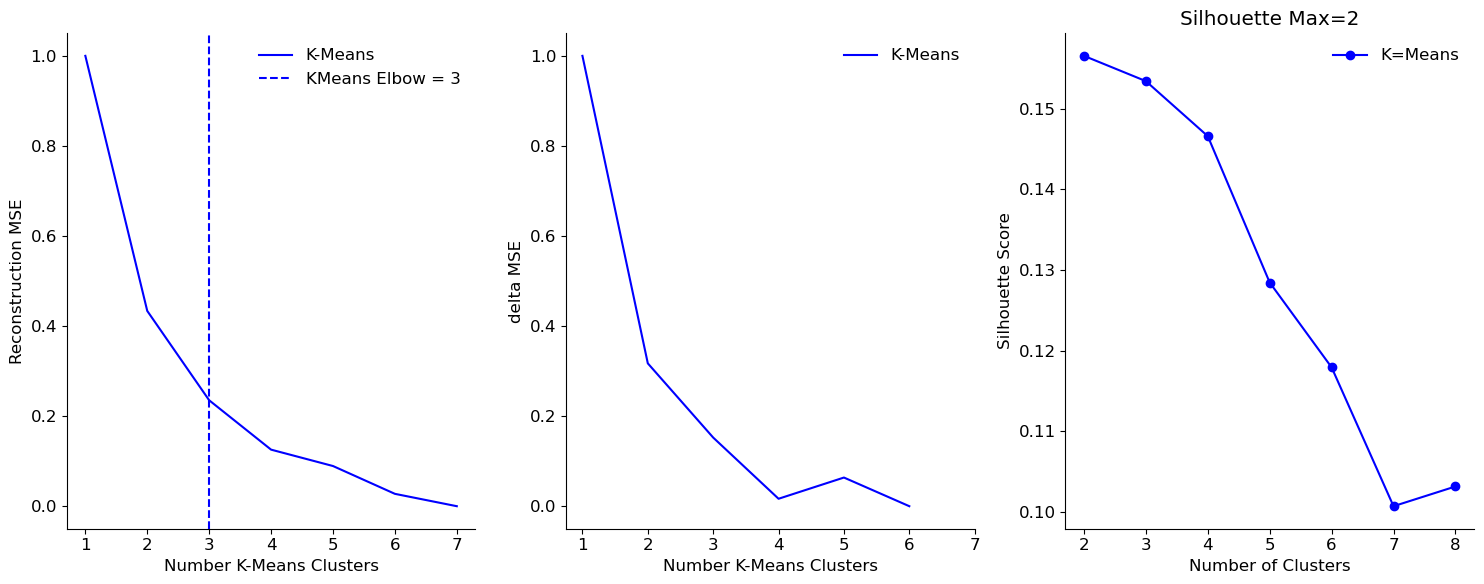

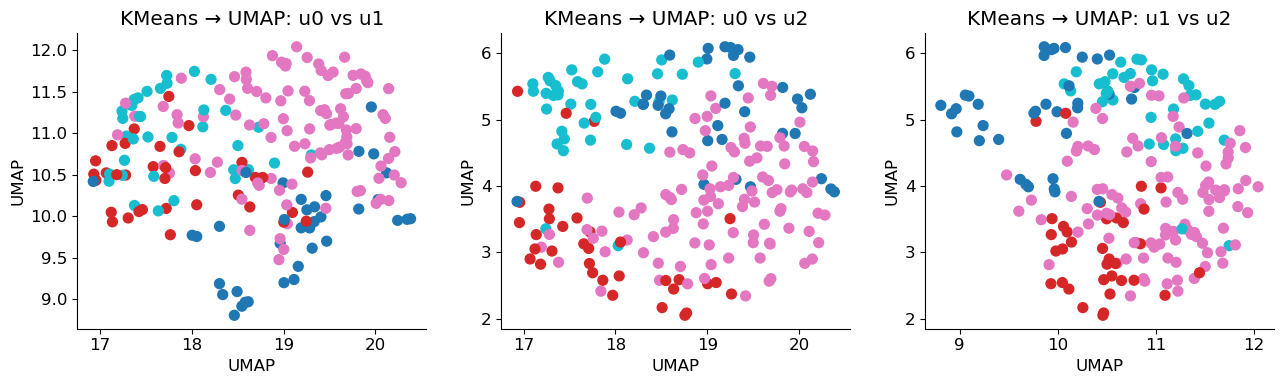

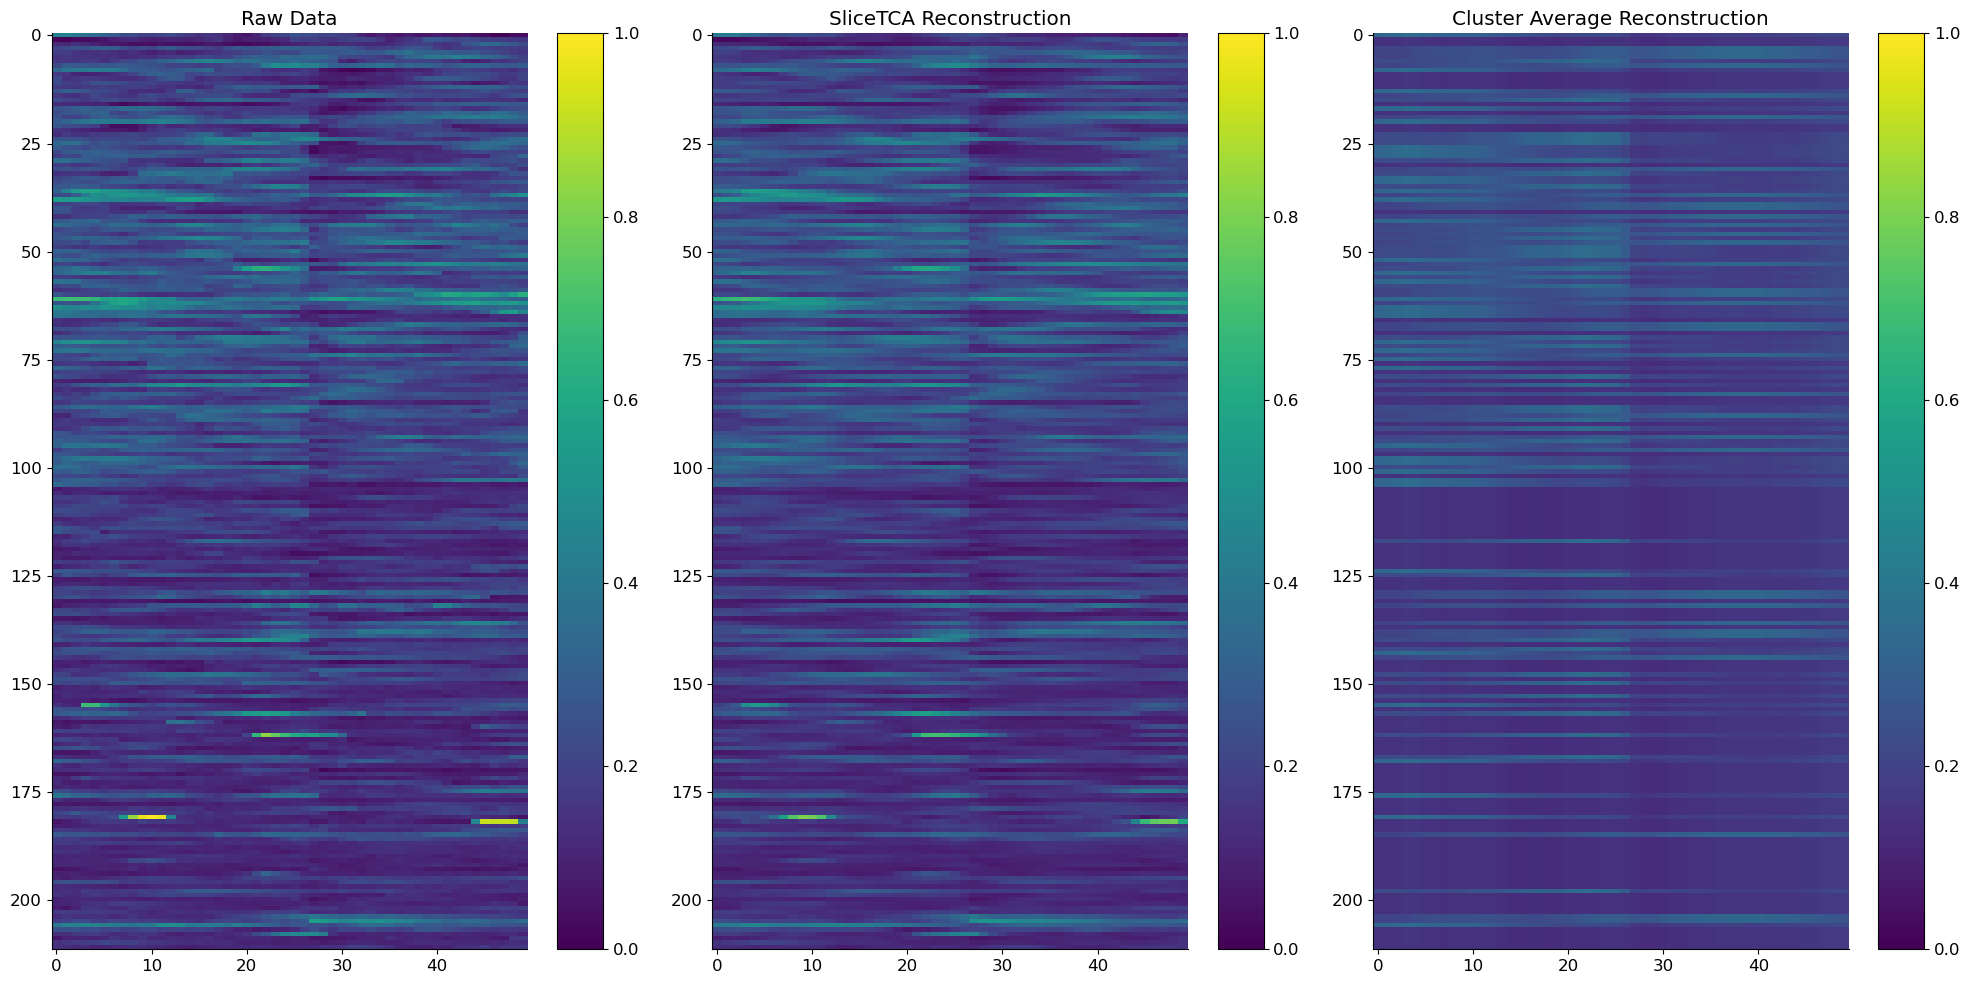

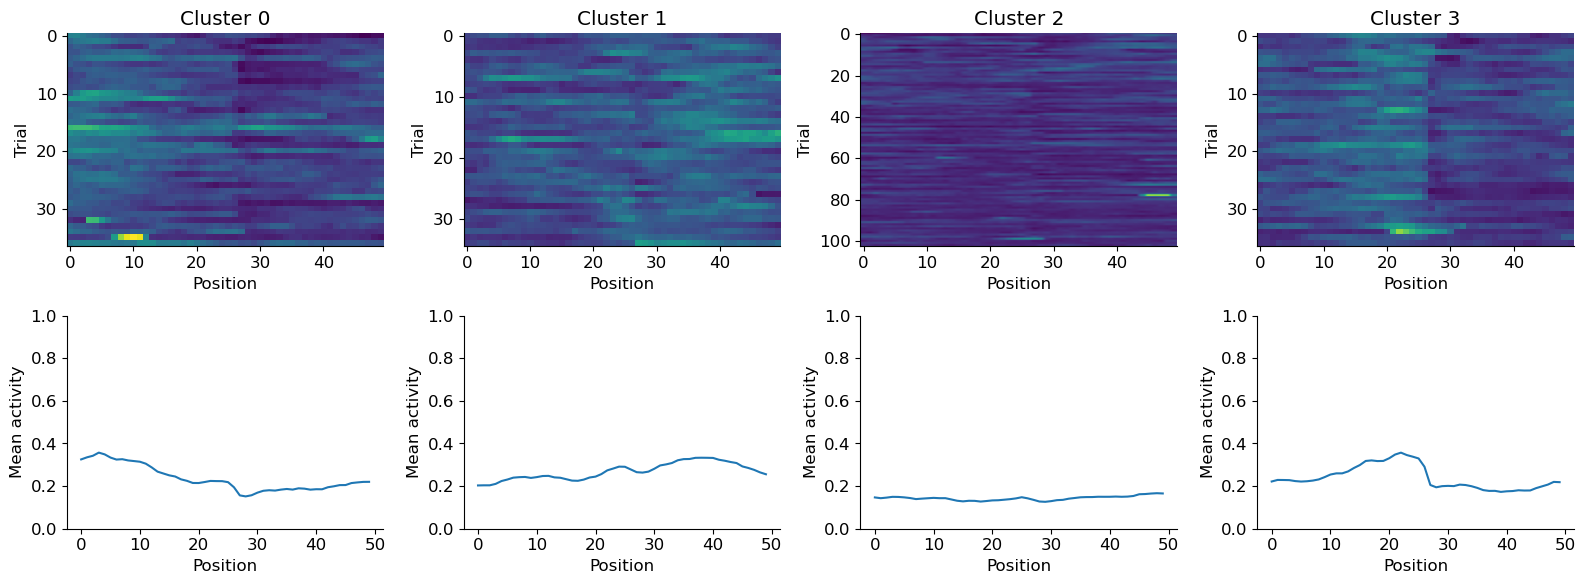

clusters_chosen_4


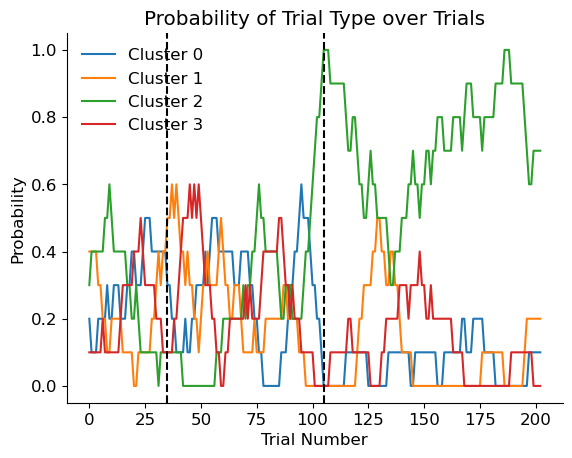

In [194]:

def plot_clustered_cell_example_summary(testing_cell_super_new_NDNF_model_ranks20_reassign_regkmean_x00_cell, residual_activity_dict_NDNF_new, cell_SST_model_ranks20_contig_x00, num_clusters=3, animal_num=2, cell_num=2, threeD_umap=True):

 
    warnings.filterwarnings("ignore", message=".*KMeans is known to have a memory leak.*")
    warnings.filterwarnings("ignore", message=".*n_jobs value 1 overridden to 1.*")
    
    MSE_array_min_max, difference_MSE_array_min_max, elbow_kmeans, cluster_range, silhouette_scores, max_silhouette_reg = compare_umap_kmeans(testing_cell_super_new_NDNF_model_ranks20_reassign_regkmean_x00_cell, animal=animal_num, cell=cell_num)
    plot_kmeans_clusters_silhouette(MSE_array_min_max, difference_MSE_array_min_max, elbow_kmeans, cluster_range, silhouette_scores, max_silhouette_reg)
    
    if num_clusters:
        clusters = num_clusters
    else:
        clusters = elbow_kmeans
    
    get_plot_umap(testing_cell_super_new_NDNF_model_ranks20_reassign_regkmean_x00_cell, k=clusters, use_3d_umap=threeD_umap, umap_seed=42, animal=animal_num, cell=cell_num)

    plot_per_cell_clustering_internals_single_cluster(testing_cell_super_new_NDNF_model_ranks20_reassign_regkmean_x00_cell, residual_activity_dict_NDNF_new, animal_id=animal_num, cell_id=cell_num, num_clusters=clusters)
    
    label_probs = get_label_probs(testing_cell_super_new_NDNF_model_ranks20_reassign_regkmean_x00_cell, clusters, animal=animal_num, cell=cell_num)
    
    cell_first_changepoints_list_SST, fraction_cell_first_changepoints_list_SST, cell_second_changepoints_list_SST, fraction_cell_second_changepoints_list_SST = get_changepoints(cell_SST_model_ranks20_contig_x00, residual_activity_dict_NDNF_new, animal_TCA=False)
    
    early_changepoint = cell_first_changepoints_list_SST[animal_num][cell_num]
    late_changepoint = cell_second_changepoints_list_SST[animal_num][cell_num]
    
    for trial_type in label_probs:
        plt.plot(label_probs[trial_type], label=f"Cluster {trial_type}")
    plt.legend()
    plt.title("Probability of Trial Type over Trials")
    plt.ylabel("Probability")
    plt.xlabel("Trial Number")
    plt.axvline(early_changepoint, linestyle="--", color='k')
    plt.axvline(late_changepoint, linestyle="--", color='k')
    plt.show()
    
plot_clustered_cell_example_summary(testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell, residual_activity_dict_SST, cell_SST_model_ranks20_contig_x00, num_clusters=4, animal_num=0, cell_num=2, threeD_umap=True)

In [186]:
cell_first_changepoints_list_SST, fraction_cell_first_changepoints_list_SST, cell_second_changepoints_list_SST, fraction_cell_second_changepoints_list_SST = get_changepoints(cell_SST_model_ranks20_contig_x00, residual_activity_dict_SST, animal_TCA=False)

[[15, 10, 35, 10, 90], [35, 10, 65, 35, 115, 115, 25, 60, 25, 40, 25, 60, 45, 30, 15], [5, 15, 15, 25, 15, 15], [20, 15, 15, 20], [50, 40, 10, 30, 40, 15, 30, 10, 5, 10, 40, 15, 30], [85, 25, 40, 75, 15, 50, 75, 20, 80, 90, 35, 85, 80], [40, 40, 25], [50, 10, 155], [5, 25, 15], [10, 105, 65, 50, 55, 70, 90, 15, 40, 5]]


In [27]:
cell=10
testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell[20][4][cell][1][f"cell_{cell}"]["labels_dict"]["clusters_chosen_7"]

array([6, 1, 1, 0, 1, 5, 5, 2, 5, 1, 1, 5, 5, 3, 1, 5, 1, 6, 3, 0, 5, 3,
       1, 1, 5, 1, 1, 1, 1, 1, 1, 1, 5, 2, 1, 5, 6, 0, 1, 1, 1, 1, 1, 1,
       0, 0, 1, 5, 2, 5, 1, 1, 1, 5, 0, 1, 1, 1, 1, 3, 1, 5, 5])

In [ ]:
cell_first_changepoints_list_SST, fraction_cell_first_changepoints_list_SST, cell_second_changepoints_list_SST, fraction_cell_second_changepoints_list_SST = get_changepoints(cell_SST_model_ranks20_contig_x00, residual_activity_dict_SST, animal_TCA=False)
    
early_changepoint = cell_first_changepoints_list_SST[0][0]
late_changepoint = cell_second_changepoints_list_SST[0][0]

In [129]:
###################### MSE between the changepoint averages to assay learning 

per_cell_diff_score_new_NDNF = get_diff_score(fixed_cell_NDNF_model_ranks20_contiguous_x00_cell, animal=False)
per_cell_diff_score_SST = get_diff_score(cell_SST_model_ranks20_contig_x00, animal=False)
per_cell_diff_score_EC = get_diff_score(cell_EC_model_ranks20_contig_x00, animal=False)
per_cell_diff_score_combined_new_old_NDNF = get_diff_score(fixed_cell_combined_NDNF_model_ranks20_contiguous_x00_cell, animal=False)

per_animal_diff_score_new_NDNF = get_diff_score(fixed_internals_animal_NDNF_model_ranks20_contiguous_x00_cell, animal=True)
per_animal_diff_score_SST = get_diff_score(internals_per_animal_dict_SST_animal_x00_contig, animal=True)
per_animal_diff_score_EC = get_diff_score(internals_per_animal_dict_EC_animal_x00_contig, animal=True)
per_animal_diff_score_combined_new_old_NDNF = get_diff_score(fixed_internals_animal_combined_NDNF_model_ranks20_contiguous_x00_cell, animal=True)

cell_ealy_mid_list_SST, cell_ealy_late_list_SST, cell_late_mid_list_SST, cell_overall_list_SST = get_MSE_contig_eml(per_cell_diff_score_SST, use_animal=False)
animal_ealy_mid_list_SST, animal_ealy_late_list_SST, animal_late_mid_list_SST, animal_overall_list_SST = get_MSE_contig_eml(per_animal_diff_score_SST, use_animal=True)
cell_ealy_mid_list_new_NDNF, cell_ealy_late_list_new_NDNF, cell_late_mid_list_new_NDNF, cell_overall_list_new_NDNF = get_MSE_contig_eml(per_cell_diff_score_new_NDNF, use_animal=False)
animal_ealy_mid_list_new_NDNF, animal_ealy_late_list_new_NDNF, animal_late_mid_list_new_NDNF, animal_overall_list_new_NDNF = get_MSE_contig_eml(per_animal_diff_score_new_NDNF, use_animal=True)
cell_ealy_mid_list_combined_NDNF, cell_ealy_late_list_combined_NDNF, cell_late_mid_list_combined_NDNF, cell_overall_list_combined_NDNF = get_MSE_contig_eml(per_cell_diff_score_combined_new_old_NDNF, use_animal=False)
animal_ealy_mid_list_combined_NDNF, animal_ealy_late_list_combined_NDNF, animal_late_mid_list_combined_NDNF, animal_overall_list_combined_NDNF = get_MSE_contig_eml(per_animal_diff_score_combined_new_old_NDNF, use_animal=True)
cell_ealy_mid_list_EC, cell_ealy_late_list_EC, cell_late_mid_list_EC, cell_overall_list_EC = get_MSE_contig_eml(per_cell_diff_score_EC, use_animal=False)
animal_ealy_mid_list_EC, animal_ealy_late_list_EC, animal_late_mid_list_EC, animal_overall_list_EC = get_MSE_contig_eml(per_animal_diff_score_EC, use_animal=True)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
    EC   NDNF  -0.0027 0.0018 -0.0045 -0.0008   True
    EC    SST   0.0002 0.9776 -0.0017   0.002  False
  NDNF    SST   0.0028 0.0192  0.0004  0.0053   True
----------------------------------------------------


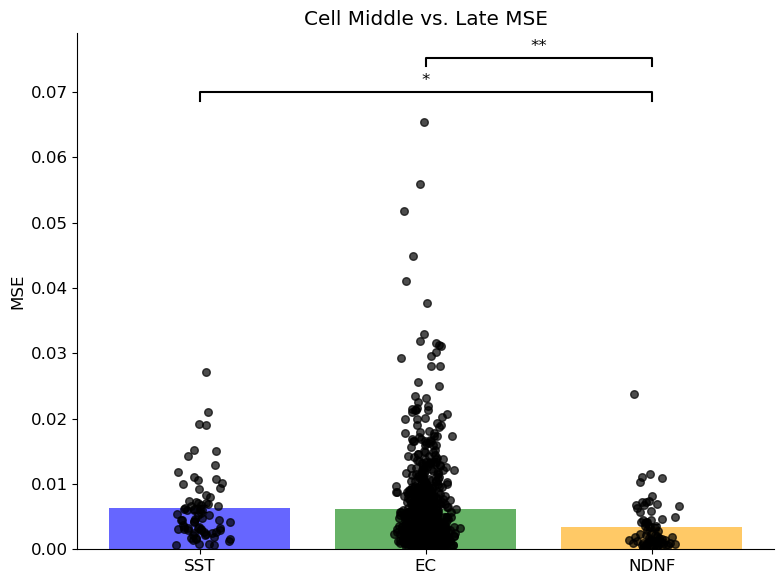

In [136]:
############## Just the new NDNF

# #Cell overall 
data = [cell_overall_list_SST, cell_overall_list_EC, cell_overall_list_new_NDNF]
plot_comparison(data, title='Cell Early, Middle, Late Overall MSE', ylabel='MSE')

# cell early middle 
data = [cell_ealy_mid_list_SST, cell_ealy_mid_list_EC, cell_ealy_mid_list_new_NDNF]
plot_comparison(data, title='Cell Early vs. Middle MSE', ylabel='MSE')

# #Cell Early vs Late
data = [cell_ealy_late_list_SST, cell_ealy_late_list_EC, cell_ealy_late_list_new_NDNF]
plot_comparison(data, title='Cell Early vs. Late MSE', ylabel='MSE')

# #Cell Middke vs Late
data = [cell_late_mid_list_SST, cell_late_mid_list_EC, cell_late_mid_list_new_NDNF]
plot_comparison(data, title='Cell Middle vs. Late MSE', ylabel='MSE')

# #animal overall 
data = [animal_overall_list_SST, animal_overall_list_EC, animal_overall_list_new_NDNF]
plot_comparison(data, title='Animal Early, Middle, Late Overall MSE', ylabel='MSE')

#animal Early vs Middle 
data = [animal_ealy_mid_list_SST, animal_ealy_mid_list_EC, animal_ealy_mid_list_new_NDNF]
plot_comparison(data, title='Animal Early vs. Middle MSE', ylabel='MSE')

#animal Early vs Late
data = [animal_ealy_late_list_SST, animal_ealy_late_list_EC, animal_ealy_late_list_new_NDNF]
plot_comparison(data, title='Animal Early vs. Late MSE', ylabel='MSE')

#animal middle vs late 
data = [animal_late_mid_list_SST, animal_late_mid_list_EC, animal_late_mid_list_new_NDNF]
plot_comparison(data, title='Animal Middle vs. Late MSE', ylabel='MSE')

##################### new and old NDNF

# #Cell overall 
data = [cell_overall_list_SST, cell_overall_list_EC, cell_overall_list_combined_NDNF]
plot_comparison(data, title='Combined Cell Early, Middle, Late Overall MSE', ylabel='MSE')

# #Cell Early vs Middle 
data = [cell_ealy_mid_list_SST, cell_ealy_mid_list_EC, cell_ealy_mid_list_combined_NDNF]
plot_comparison(data, title='Combined Cell Early vs. Middle MSE', ylabel='MSE')

# #Cell Early vs Late
data = [cell_ealy_late_list_SST, cell_ealy_late_list_EC, cell_ealy_late_list_combined_NDNF]
plot_comparison(data, title='Combined Cell Early vs. Late MSE', ylabel='MSE')

# #Cell Middke vs Late
data = [cell_late_mid_list_SST, cell_late_mid_list_EC, cell_late_mid_list_combined_NDNF]
plot_comparison(data, title='Combined Cell Middle vs. Late MSE', ylabel='MSE')

# #animal overall 
data = [animal_overall_list_SST, animal_overall_list_EC, animal_overall_list_combined_NDNF]
plot_comparison(data, title='Combined Animal Early, Middle, Late Overall MSE', ylabel='MSE')

# #animal Early vs Middle 
data = [animal_ealy_mid_list_SST, animal_ealy_mid_list_EC, animal_ealy_mid_list_combined_NDNF]
plot_comparison(data, title='Combined Animal Early vs. Middle MSE', ylabel='MSE')

# #animal Early vs Late
data = [animal_ealy_late_list_SST, animal_ealy_late_list_EC, animal_ealy_late_list_combined_NDNF]
plot_comparison(data, title='Combined Animal Early vs. Late MSE', ylabel='MSE')

#animal middle vs late 
data = [animal_late_mid_list_SST, animal_late_mid_list_EC, animal_late_mid_list_combined_NDNF]
plot_comparison(data, title='Combined Animal Middle vs. Late MSE', ylabel='MSE')